# Medical Billing Research Project
## 02 — Data Preparation (Section 3.2)

**Follows:** 01_data_understanding.ipynb
**Saves to:** ../dataset/private_patient_clean.csv

### What Happens In This Notebook
This notebook covers all steps in Section 3.2 of the methodology,
executed in the following order:

- **3.2.1 Variable Screening** — reduce 32 variables to relevant ones
- **3.2.2 Anomaly Detection** — examine and fix each retained variable
- **3.2.3 Missing Values** — assess and treat all missing values
- **3.2.4 Feature Engineering** — build new variables including target
- **3.2.5 Correlations and Associations** — check for multicollinearity
- **3.2.6 Descriptive Analyses** — explore the final clean dataset
- **3.2.7 Data Partitioning** — split into training and test sets

### Rule
No variable is modified without a documented reason.
Every number in this notebook must match the report exactly.

In [1]:
# ============================================================
# CELL 1: IMPORTS AND LOAD RAW DATA
# We reload the original raw file fresh — this notebook does
# not depend on anything from the data understanding notebook.
# Every transformation starts from the clean raw source.
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency, pointbiserialr

# Display settings — show all columns and clean decimals
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
pd.set_option('display.float_format', '{:.2f}'.format)

# Load the original raw xlsx file
# We always start from raw — never from a previously saved file
df = pd.read_excel(
    r'C:\2026\MedicalBillingResearch\dataset\PRIVATE PATIENT.xlsx',
    engine='openpyxl'
)

# Confirm we have the correct dataset before doing anything
print("=" * 60)
print("RAW DATA LOADED — CONFIRMATION")
print("=" * 60)
print(f"  Rows    : {df.shape[0]:,}")
print(f"  Columns : {df.shape[1]}")
print(f"  Expected: 50,000 rows x 32 columns")
print(f"  Status  : "
      f"{'OK' if df.shape == (50000, 32) else 'MISMATCH — CHECK FILE'}")

RAW DATA LOADED — CONFIRMATION
  Rows    : 50,000
  Columns : 32
  Expected: 50,000 rows x 32 columns
  Status  : OK


## 3.2.1 Variable Screening

We reduce the dataset from 32 variables to only those relevant
for modelling. Variables are excluded based on four criteria:

- **Identifiers** — hashed or anonymised, no predictive value
- **Constants** — single value across all records, zero variation
- **Post-capture outcomes** — values develop after invoice is
  processed, including them would be data leakage
- **Redundant** — same information captured in another variable

Variables marked Engineer are not kept as-is but will produce
a new derived variable during Feature Engineering (3.2.4).

In [2]:
# ============================================================
# CELL 2: VARIABLE SCREENING (Section 3.2.1)
# We define which variables to keep, exclude, or engineer.
# This is based on what we discovered in data understanding.
# Every exclusion has a documented reason.
# ============================================================

# ── Define our screening decisions ───────────────────────
# Format: 'Variable Name': ('Decision', 'Reason')
screening = {
    'Invoice Number':               ('Track',
        'Not a true identifier — kept only for record tracking, not modelling'),
    'Entity name':                  ('Exclude',
        'Hashed practice identifier — anonymised, no predictive value'),
    'Main Member':                  ('Exclude',
        'Hashed account holder identifier — anonymised, no predictive value'),
    'Medical Aid Number':           ('Exclude',
        'Hashed field — populated with system default, not real scheme numbers'),
    'Invoice Date':                 ('Exclude',
        'Not used as predictor — only used to validate date logic during cleaning'),
    'Capture Date':                 ('Keep',
        'Start point of processing timeline — used to build target variable'),
    'Earliest Capture Date':        ('Exclude',
        'Not used as predictor — only used for date logic validation'),
    'Latest Capture Date':          ('Keep',
        'End point of processing timeline — used to build target variable'),
    'Service Centre':               ('Engineer',
        '730 unique values — too many for modelling, engineer into Facility Type'),
    'Treating Doctor':              ('Exclude',
        'Hashed identifier — 566 unique values, one linked to 41 specialties, unusable'),
    'Referring Doctor Name':        ('Engineer',
        'Hashed — engineer into binary Has Referral indicator (0/1)'),
    'Scheme':                       ('Exclude',
        'Constant — single value PRIVATE PATIENT across all 50,000 records'),
    'Option':                       ('Keep',
        '6 billing designation categories — valid predictor'),
    'Administrator':                ('Exclude',
        'Constant — single value PRIVATE across all 50,000 records'),
    'Posted Billing Group':         ('Keep',
        'Billing rate category — requires cleaning, valid predictor'),
    'ICD10 String':                 ('Exclude',
        'Raw text duplicate of Primary ICD10 — noisier, redundant'),
    'Primary ICD10':                ('Engineer',
        '2,387 unique codes — engineer into ICD10 Chapter groups'),
    'ICD10 Description':            ('Exclude',
        'Plain English duplicate of Primary ICD10 — redundant'),
    'Patient Name':                 ('Exclude',
        'Hashed identifier — 468 missing, no predictive value'),
    'Patient DOB':                  ('Exclude',
        '42.48% missing, earliest date year 0101 — corrupted, unusable'),
    'Gender':                       ('Keep',
        'Patient gender — requires V consolidation and missing treatment'),
    'Specialty':                    ('Keep',
        '118 values — requires standardisation, valid predictor'),
    'Debtor Status':                ('Keep',
        'Payment status — requires cleaning of 20 inconsistent categories'),
    'POSSIBLE PMB CALCULATED':      ('Keep',
        'Clean binary — PMB vs NON-PMB, no missing values'),
    'CONTRACTED/NON-CONTRACTED':    ('Keep',
        'Clean binary — CONTRACTED vs NON-CONTRACTED, no missing values'),
    'Age Bracket':                  ('Keep',
        '7 ordered debt aging categories — treat as ordered categorical'),
    'Total Outstanding':            ('Exclude',
        'Post-capture outcome — 97% zero, data leakage risk'),
    'Total Medical Aid Outstanding':('Exclude',
        'Post-capture outcome — 99.75% zero, data leakage risk'),
    'Total Patient Outstanding':    ('Exclude',
        'Post-capture outcome — data leakage risk'),
    'Total Turnover':               ('Keep',
        'Billed amount — known at capture, requires log transformation'),
    'Total Cashflow':               ('Exclude',
        'Post-capture outcome — money received after processing'),
    'Total Journals':               ('Exclude',
        'Post-capture accounting adjustment — 93.67% missing'),
}

# ── Print screening summary ───────────────────────────────
print("=" * 60)
print("VARIABLE SCREENING DECISIONS (Section 3.2.1)")
print("=" * 60)

decisions = {}
for var, (decision, reason) in screening.items():
    if decision not in decisions:
        decisions[decision] = []
    decisions[decision].append(var)

for decision, vars_list in decisions.items():
    print(f"\n  {decision} ({len(vars_list)} variables):")
    for v in vars_list:
        print(f"    - {v}")
        print(f"      Reason: {screening[v][1]}")

# ── Apply screening — keep only relevant columns ──────────
# We keep: Track + Keep + Engineer columns
# Exclude columns are dropped here permanently
cols_to_keep = [
    var for var, (decision, _) in screening.items()
    if decision in ('Track', 'Keep', 'Engineer')
]

df = df[cols_to_keep].copy()

# ── Confirm reduction ─────────────────────────────────────
print("\n" + "=" * 60)
print("DATASET AFTER VARIABLE SCREENING")
print("=" * 60)
print(f"  Variables before screening : 32")
print(f"  Variables excluded         : "
      f"{sum(1 for d,_ in screening.values() if d == 'Exclude')}")
print(f"  Variables retained         : {df.shape[1]}")
print(f"  Records unchanged          : {df.shape[0]:,}")
print(f"\n  Retained columns:")
for col in df.columns:
    decision = screening[col][0]
    print(f"    [{decision:<8}] {col}")

VARIABLE SCREENING DECISIONS (Section 3.2.1)

  Track (1 variables):
    - Invoice Number
      Reason: Not a true identifier — kept only for record tracking, not modelling

  Exclude (17 variables):
    - Entity name
      Reason: Hashed practice identifier — anonymised, no predictive value
    - Main Member
      Reason: Hashed account holder identifier — anonymised, no predictive value
    - Medical Aid Number
      Reason: Hashed field — populated with system default, not real scheme numbers
    - Invoice Date
      Reason: Not used as predictor — only used to validate date logic during cleaning
    - Earliest Capture Date
      Reason: Not used as predictor — only used for date logic validation
    - Treating Doctor
      Reason: Hashed identifier — 566 unique values, one linked to 41 specialties, unusable
    - Scheme
      Reason: Constant — single value PRIVATE PATIENT across all 50,000 records
    - Administrator
      Reason: Constant — single value PRIVATE across all 50,000 

## 3.2.2 Anomaly Detection

Each retained variable is examined individually for anomalies.
For every variable we document:
1. What anomaly was found
2. What assumption we made about it
3. What correction was applied

No variable is modified without all three being documented.
We work through variables in this order:
- Date variables first (Capture Date, Latest Capture Date)
- Categorical variables
- Numeric variables

In [3]:
# ============================================================
# CELL 3: ANOMALY DETECTION — DATE VARIABLES (Section 3.2.2)
# We examine Capture Date and Latest Capture Date.
# These two variables build our target variable so they must
# be clean before anything else happens.
# Invoice Date is also loaded here temporarily — we need it
# only to validate the date logic and then we discard it.
# ============================================================

# ── Temporarily reload Invoice Date for validation only ───
# We excluded it from df during screening but we need it now
# to check whether Capture Date and Latest Capture Date are
# logically consistent relative to the invoice creation date
invoice_date_temp = pd.read_excel(
    r'C:\2026\MedicalBillingResearch\dataset\PRIVATE PATIENT.xlsx',
    engine='openpyxl',
    usecols=['Invoice Number', 'Invoice Date']
)

# Merge temporarily into df just for validation checks
df_check = df.merge(invoice_date_temp, on='Invoice Number', how='left')

print("=" * 60)
print("DATE VARIABLE ANOMALY CHECKS")
print("=" * 60)

# ── Check 1: Capture Date before Invoice Date ─────────────
# An invoice cannot be captured before it was created
# This would mean the billing system recorded it before
# the service even happened — impossible
cap_before_inv = (
    df_check['Capture Date'] < df_check['Invoice Date']
).sum()
print(f"\n  Capture Date before Invoice Date    : {cap_before_inv:,} records")

# ── Check 2: Latest Capture Date before Capture Date ─────
# Latest activity cannot be before first capture
# This would mean the last update happened before the first
# entry — logically impossible
latest_before_cap = (
    df_check['Latest Capture Date'] < df_check['Capture Date']
).sum()
print(f"  Latest Capture before Capture Date  : {latest_before_cap:,} records")

# ── Check 3: Latest Capture Date before Invoice Date ─────
# This is the most critical check for our target variable
# If Latest Capture Date < Invoice Date then
# Latest Capture Date - Capture Date could still be valid
# but we flag these for review
latest_before_inv = (
    df_check['Latest Capture Date'] < df_check['Invoice Date']
).sum()
print(f"  Latest Capture before Invoice Date  : {latest_before_inv:,} records")

# ── Check 4: Future Invoice Dates ────────────────────────
# Any Invoice Date after today (May 2026) is impossible
future_inv = (
    df_check['Invoice Date'] > pd.Timestamp('2026-05-02')
).sum()
print(f"  Invoice Date in the future (>today) : {future_inv:,} records")

# ── Show the problematic records in detail ────────────────
# We look at records where Latest Capture Date < Invoice Date
# These directly break our target variable calculation
print(f"\n  Detail — records where Latest Capture < Invoice Date:")
problematic = df_check[
    df_check['Latest Capture Date'] < df_check['Invoice Date']
][['Invoice Number', 'Invoice Date', 'Capture Date',
   'Latest Capture Date']].copy()

# Calculate what the processing time would be for these
problematic['Would-be Processing Days'] = (
    problematic['Latest Capture Date'] -
    problematic['Capture Date']
).dt.days

print(problematic.to_string(index=False))

# ── Check 5: Missing Invoice Dates ───────────────────────
# Records with no Invoice Date — we need to decide what
# happens to these since they have no reference start point
missing_inv = df_check['Invoice Date'].isnull().sum()
print(f"\n  Records with missing Invoice Date   : {missing_inv:,}")
print(f"\n  Note: Invoice Date is used only for validation.")
print(f"  Our target variable uses Capture Date as start point.")
print(f"  Records where Latest Capture Date < Capture Date")
print(f"  are the ones that would break our calculation.")
print(f"  Those count: {latest_before_cap:,}")

DATE VARIABLE ANOMALY CHECKS

  Capture Date before Invoice Date    : 35,336 records
  Latest Capture before Capture Date  : 0 records
  Latest Capture before Invoice Date  : 34,193 records
  Invoice Date in the future (>today) : 3 records

  Detail — records where Latest Capture < Invoice Date:
Invoice Number Invoice Date Capture Date Latest Capture Date  Would-be Processing Days
    00000406/X   2024-04-15   2020-07-20          2022-08-04                       745
    00000406/X   2024-07-22   2020-07-20          2022-08-04                       745
    R0000006/P   2024-02-28   2022-11-30          2022-11-30                         0
    R0000006/P   2023-12-27   2022-11-30          2022-11-30                         0
    R0000005/P   2023-12-25   2023-06-20          2023-06-20                         0
    R0000005/P   2024-04-26   2023-06-20          2023-06-20                         0
    00000002/X   2023-08-15   2023-02-16          2023-02-16                         0
    000

In [4]:
# ============================================================
# CELL 4: ANOMALY DETECTION — OPTION AND GENDER (Section 3.2.2)
# We fix Option and Gender first as they are straightforward.
# Option: review the 6 categories and decide on minor ones
# Gender: consolidate V into F, assign blanks to Unknown
# ============================================================

# ── OPTION ───────────────────────────────────────────────
# We saw 6 categories in data understanding
# 98.61% is PRIVATE PATIENT ACUTE
# PRIVATE INSURANCE RATE (15 records) are not pure private
# patients — they have some insurance cover
# We examine whether to consolidate or exclude these
print("=" * 60)
print("VARIABLE: Option — Before Cleaning")
print("=" * 60)
print(df['Option'].value_counts(dropna=False).to_string())

# Consolidate the categories
# PRIVATE PATIENT PRIVATE PATIENT SEP ACUT and
# PRIVATE PATIENT PRIVATE PATIENT PHARMACY both have
# PRIVATE PATIENT duplicated in the label — data entry error
# We standardise all legitimate private patient categories
# PRIVATE INSURANCE RATE is kept as its own category since
# it represents a meaningfully different billing arrangement

option_mapping = {
    'PRIVATE PATIENT ACUTE':                       'Private Patient Acute',
    'PRIVATE PATIENT COST ACUTE':                  'Private Patient Acute',
    'PRIVATE PATIENT PRIVATE PATIENT SEP ACUT':    'Private Patient Acute',
    'PRIVATE ACUTE':                               'Private Patient Acute',
    'PRIVATE INSURANCE RATE':                      'Private Insurance',
    'PRIVATE PATIENT PRIVATE PATIENT PHARMACY':    'Private Patient Pharmacy',
}

df['Option'] = df['Option'].map(option_mapping)

print("\nVariable: Option — After Cleaning")
print("=" * 60)
print(df['Option'].value_counts(dropna=False).to_string())

# ── GENDER ────────────────────────────────────────────────
# V (67 records) represents Vroulik — Afrikaans for Female
# We consolidate V into F
# Blank entries become Unknown — we do not impute gender
# because assuming a patient's gender is not appropriate
print("\n" + "=" * 60)
print("VARIABLE: Gender — Before Cleaning")
print("=" * 60)
print(df['Gender'].value_counts(dropna=False).to_string())

# Apply corrections
df['Gender'] = df['Gender'].fillna('Unknown')
df['Gender'] = df['Gender'].replace('V', 'F')

print("\nVariable: Gender — After Cleaning")
print("=" * 60)
print(df['Gender'].value_counts(dropna=False).to_string())

# ── Confirm no unexpected values remain ───────────────────
print("\nExpected values: F, M, Unknown only")
unexpected_gender = df[~df['Gender'].isin(['F', 'M', 'Unknown'])]['Gender'].unique()
print(f"Unexpected values found: {unexpected_gender if len(unexpected_gender) > 0 else 'None'}")

VARIABLE: Option — Before Cleaning
Option
PRIVATE PATIENT ACUTE                       49304
PRIVATE PATIENT COST ACUTE                    440
PRIVATE PATIENT PRIVATE PATIENT SEP ACUT      190
PRIVATE ACUTE                                  47
PRIVATE INSURANCE RATE                         15
PRIVATE PATIENT PRIVATE PATIENT PHARMACY        4

Variable: Option — After Cleaning
Option
Private Patient Acute       49981
Private Insurance              15
Private Patient Pharmacy        4

VARIABLE: Gender — Before Cleaning
Gender
F      25229
M      23311
NaN     1393
V         67

Variable: Gender — After Cleaning
Gender
F          25296
M          23311
Unknown     1393

Expected values: F, M, Unknown only
Unexpected values found: None


In [5]:
# ============================================================
# CELL 5: ANOMALY DETECTION — DEBTOR STATUS (Section 3.2.2)
# Debtor Status had 20 categories with multiple problems:
# capitalisation inconsistencies, administrative labels,
# non-private-patient categories, and near-duplicate entries.
# We clean systematically — fix casing first, then consolidate.
# ============================================================

print("=" * 60)
print("VARIABLE: Debtor Status — Before Cleaning")
print("=" * 60)
print(df['Debtor Status'].value_counts(dropna=False).to_string())

# ── Step 1: Fix capitalisation inconsistencies ────────────
# ESTATE and Estate are the same category — different casing
# private patient should be Private Patient
df['Debtor Status'] = df['Debtor Status'].replace({
    'ESTATE':          'Estate',
    'private patient': 'Private Patient',
})

# ── Step 2: Consolidate problematic administrative labels ─
# DO NOT USE — internal system flag, not a real status
# Check Notes and PMB/Check notes — admin notes, not statuses
# No Balance Billing — billing instruction, not a status
# Pt Information form outstandin — truncated data entry error
# We consolidate these into Other as they are too small and
# too ambiguous to form meaningful categories
admin_labels = [
    'DO NOT USE',
    'Check Notes',
    'PMB/Check notes',
    'No Balance Billing',
    'Pt Information form outstandin'
]
df['Debtor Status'] = df['Debtor Status'].replace(
    {label: 'Other' for label in admin_labels}
)

# ── Step 3: Handle WCA and RAF ────────────────────────────
# WCA = Workmen's Compensation Act cases
# RAF = Road Accident Fund cases
# Neither are true private patients — they are billed through
# compensation funds. However they are in our dataset and
# removing them changes our record count.
# We keep them but consolidate into Other since they behave
# differently from standard private patient billing
df['Debtor Status'] = df['Debtor Status'].replace({
    'WCA': 'Other',
    'RAF': 'Other',
})

# ── Step 4: Consolidate small Handed Over categories ──────
# Handed over ACK, Handed over MEDICOL, Handed over OTHER
# all represent the same outcome — debt handed to collection
# The distinction between collection agencies is not relevant
# to our model — what matters is that it was handed over
df['Debtor Status'] = df['Debtor Status'].replace({
    'Handed over ACK':     'Active Collection',
    'Handed over MEDICOL': 'Active Collection',
    'Handed over OTHER':   'Active Collection',
    'To be handed over':   'Active Collection',
    'ITC listed':          'Active Collection',
    'Final point of contact': 'Active Collection',
})

# ── Step 5: Consolidate Discontinued ─────────────────────
# Discontinued means billing was stopped — similar in outcome
# to Other administrative categories
df['Debtor Status'] = df['Debtor Status'].replace({
    'Discontinued': 'Other',
})

print("\nVariable: Debtor Status — After Cleaning")
print("=" * 60)
vc = df['Debtor Status'].value_counts(dropna=False)
total = len(df)
for status, count in vc.items():
    pct = count / total * 100
    print(f"  {status:<25} {count:>6} ({pct:.2f}%)")

# ── Confirm total records unchanged ──────────────────────
print(f"\n  Total records : {total:,}")
print(f"  Unique categories remaining : {df['Debtor Status'].nunique()}")

VARIABLE: Debtor Status — Before Cleaning
Debtor Status
Normal                            47120
Payment arrangement                 845
Deceased                            589
To be handed over                   380
Handed over ACK                     364
Handed over MEDICOL                 177
WCA                                 132
Handed over OTHER                   102
private patient                      81
Discontinued                         73
Final point of contact               68
RAF                                  21
Estate                               18
DO NOT USE                           12
ITC listed                            9
Check Notes                           4
No Balance Billing                    2
PMB/Check notes                       1
ESTATE                                1
Pt Information form outstandin        1

Variable: Debtor Status — After Cleaning
  Normal                     47120 (94.24%)
  Active Collection           1100 (2.20%)
  Payment arran

In [6]:
# ============================================================
# CELL 6: ANOMALY DETECTION — POSTED BILLING GROUP
# Section 3.2.2
# This variable had 75 categories with spacing inconsistencies,
# duplicate labels, unknown entries and reserved system codes.
# We clean in steps — fix spacing first, then consolidate
# small and ambiguous categories into meaningful groups.
# ============================================================

print("=" * 60)
print("VARIABLE: Posted Billing Group — Before Cleaning")
print("=" * 60)
vc_before = df['Posted Billing Group'].value_counts(dropna=False)
print(f"  Unique values : {df['Posted Billing Group'].nunique()}")
print(f"  Missing       : {df['Posted Billing Group'].isnull().sum():,}")
print(f"\n  All categories:")
for val, count in vc_before.items():
    pct = count / len(df) * 100
    print(f"    {str(val):<52} {count:>5} ({pct:.2f}%)")

# ── Step 1: Fix spacing inconsistencies ───────────────────
# SCHEME RATE(1) and SCHEME RATE (1) are the same
# SCHEME RATE and SCHEME  RATE (double space) are the same
# DH RATE(2) and DH RATE (2) are the same
# PRACTICE RATE(6) and PRACTICE RATE (6) are the same
# We strip all extra spaces first to catch most cases
df['Posted Billing Group'] = df['Posted Billing Group'].str.strip()
df['Posted Billing Group'] = df['Posted Billing Group'].str.replace(
    r'\s+', ' ', regex=True
)

# Now fix specific known duplicates after spacing is normalised
df['Posted Billing Group'] = df['Posted Billing Group'].replace({
    'SCHEME RATE (1)':    'SCHEME RATE(1)',
    'SCHEME RATE':        'SCHEME RATE(1)',
    'DH RATE (2)':        'DH RATE(2)',
    'PRACTICE RATE (6)':  'PRACTICE RATE(6)',
    # Fix the record with a transaction ID appended
    'SCHEME RATE (1) (GLW41642363)': 'SCHEME RATE(1)',
    'DH RATE (2) (GLW41642365)':     'DH RATE(2)',
})

# ── Step 2: Handle missing and unknown ───────────────────
# Missing values become Unknown — we do not impute billing
# group because we cannot know what rate was applied
# The existing unknown label is also standardised
df['Posted Billing Group'] = df['Posted Billing Group'].fillna('Unknown')
df['Posted Billing Group'] = df['Posted Billing Group'].replace({
    'unknown': 'Unknown'
})

# ── Step 3: Consolidate system placeholder categories ─────
# RESERVED_100, RESERVED_81, RESERVED_82 are internal system
# codes — not real billing groups
# RAF(6) is a Road Accident Fund billing rate — not private
# 2_MAX / INSURED: %(69) is a corrupted label
# These all go into Other
reserved_labels = [
    'RESERVED_100', 'RESERVED_81', 'RESERVED_82',
    'RAF(6)', '2_MAX / INSURED: %(69)'
]
df['Posted Billing Group'] = df['Posted Billing Group'].replace(
    {label: 'Other' for label in reserved_labels}
)

# ── Step 4: Consolidate PA partner agreement categories ───
# PA: prefixed categories are partner agreement rates with
# specific medical aid schemes — these are very small in count
# We group them into Partner Agreement rate category
pa_categories = [
    cat for cat in df['Posted Billing Group'].unique()
    if str(cat).startswith('PA:')
]
df['Posted Billing Group'] = df['Posted Billing Group'].replace(
    {cat: 'Partner Agreement Rate' for cat in pa_categories}
)

# ── Step 5: Consolidate small MAX/INSURED categories ──────
# There are many MAX/INSURED variants at different percentages
# We keep the two largest ones individually as they have
# enough records to be meaningful on their own
# The rest we group by rate range into High, Medium, Low
# First let us see what remains after steps 1-4
remaining = df['Posted Billing Group'].value_counts()

# Categories with fewer than 100 records that are MAX/INSURED
# variants get consolidated based on their percentage rate
def classify_billing_group(val):
    if pd.isna(val):
        return 'Unknown'
    val = str(val)
    # Keep the large ones as-is
    if val in ['SCHEME RATE(1)', 'MAX / INSURED: 300%(20)',
               'MAX / INSURED: 200%(15)', 'DH RATE(2)',
               'Unknown', 'Other', 'Partner Agreement Rate',
               'MEDICAL AID(1)', 'SAOPA(1)', 'COID EXCL VAT(3)',
               'Partner Agreement Rate']:
        return val
    # Classify remaining MAX/INSURED by percentage
    if 'MAX / INSURED' in val or 'MAX / INSURED CSTM' in val:
        # Extract the percentage number
        import re
        match = re.search(r'(\d+)%', val)
        if match:
            pct = int(match.group(1))
            if pct >= 300:
                return 'High Billing Rate'
            elif pct >= 150:
                return 'Medium Billing Rate'
            else:
                return 'Low Billing Rate'
    # Anything else with small counts goes to Other
    return 'Other'

df['Posted Billing Group'] = df['Posted Billing Group'].apply(
    classify_billing_group
)

# ── Result ────────────────────────────────────────────────
print("\nVariable: Posted Billing Group — After Cleaning")
print("=" * 60)
vc_after = df['Posted Billing Group'].value_counts(dropna=False)
total = len(df)
for val, count in vc_after.items():
    pct = count / total * 100
    print(f"  {str(val):<30} {count:>6} ({pct:.2f}%)")

print(f"\n  Categories before : 75")
print(f"  Categories after  : {df['Posted Billing Group'].nunique()}")
print(f"  Total records     : {total:,}")

VARIABLE: Posted Billing Group — Before Cleaning
  Unique values : 75
  Missing       : 3,533

  All categories:
    SCHEME RATE(1)                                       21552 (43.10%)
    MAX / INSURED: 300%(20)                               5945 (11.89%)
    MAX / INSURED: 200%(15)                               5336 (10.67%)
    nan                                                   3533 (7.07%)
    SCHEME RATE (1)                                       3100 (6.20%)
    MAX / INSURED: 147%(103)                              1908 (3.82%)
    MAX / INSURED: 217%(107)                              1568 (3.14%)
    MAX / INSURED: 150%(13)                               1211 (2.42%)
    MAX / INSURED: 130%(11)                               1012 (2.02%)
    PA: DH PREMIER B: 147%(36)                             784 (1.57%)
    DH RATE(2)                                             686 (1.37%)
    MAX / INSURED: 162%(105)                               591 (1.18%)
    MEDICAL AID(1)              

In [7]:
# ============================================================
# CELL 7: ANOMALY DETECTION — SPECIALTY (Section 3.2.2)
# Specialty had 118 unique values due to naming inconsistencies.
# The same specialty appeared under multiple formats:
# coded format e.g. (026) Ophthalmologist
# plain name e.g. Ophthalmologist
# bare number e.g. 026
# typos e.g. Opthalmology, Psycologist, Orthapeadic Surgeon
# We standardise everything to one clean label per specialty.
# ============================================================

print("=" * 60)
print("VARIABLE: Specialty — Before Cleaning")
print("=" * 60)
print(f"  Unique values : {df['Specialty'].nunique()}")
print(f"  Missing       : {df['Specialty'].isnull().sum()}")

# ── Build comprehensive mapping ───────────────────────────
# Every variant maps to one standardised specialty name.
# Where a bare number appears we map it to the known specialty
# that code represents in the South African billing system.
specialty_mapping = {
    # Ophthalmologist variants
    '(026) Ophthalmologist':        'Ophthalmologist',
    'Ophthalmologist':              'Ophthalmologist',
    'Opthalmology':                 'Ophthalmologist',
    'Ophthalmology':                'Ophthalmologist',
    '026':                          'Ophthalmologist',

    # Physician variants
    '(018) Physician':                              'Physician',
    '(018) Physician (010) Gastroenterology':       'Physician',
    '(018) Physician (005) Pulmonology':            'Physician',
    '(018) Physician (001) Clinical Haematology':   'Physician',
    '(018) Physician (003) Cardiology':             'Physician',
    '(018) Physician (006) Critical Care':          'Physician',
    '(018) Physician (002) Nephrology':             'Physician',
    '(018) Physician (009) Infectious Diseases':    'Physician',
    '(018) Physician (012) Rheumatology':           'Physician',
    '(018) Physician (011) Medical Oncology':       'Physician',
    '(018) Physician (004) Endocrinology':          'Physician',
    'Physician':                                    'Physician',
    '018':                                          'Physician',

    # General Surgeon variants
    '(042) General Surgeon':                        'General Surgeon',
    '(042) General Surgeon (003) Gastroenterology': 'General Surgeon',
    '(042 001) Vascular Surgeon':                   'General Surgeon',
    'General Surgeon':                              'General Surgeon',
    '042':                                          'General Surgeon',

    # General Practice / GP variants
    '(014) General Medical Practice / GP':  'General Medical Practice',
    'GP':                                   'General Medical Practice',
    'GP Aneath':                            'General Medical Practice',
    '014':                                  'General Medical Practice',

    # Psychiatrist variants
    '(022) Psychiatrist':   'Psychiatrist',
    'Psychiatrist':         'Psychiatrist',
    '022':                  'Psychiatrist',

    # Paediatrician variants
    '(032) Paediatrician':                          'Paediatrician',
    '(032) Paediatrician (007) Gastroenterology':   'Paediatrician',
    '(032) Paediatrician (006) Endocrinology':      'Paediatrician',
    '(032) Paediatrician (009) Pulmonology':        'Paediatrician',
    '(032) Paediatrician (013) Cardiology':         'Paediatrician',
    'Paediatrician':                                'Paediatrician',
    '032':                                          'Paediatrician',

    # Dentist variants
    '(054) General Dental Practice':    'General Dental Practice',
    'Dentist':                          'General Dental Practice',
    '054':                              'General Dental Practice',

    # Urologist variants
    '(046) Urologist':  'Urologist',
    'Urologist':        'Urologist',
    'Urology':          'Urologist',

    # Orthopaedic Surgeon variants — including typos
    '(028) Orthopaedic Surgeon':    'Orthopaedic Surgeon',
    'Orthapeadic Surgeon':          'Orthopaedic Surgeon',
    'Orthopaedic Surgeon':          'Orthopaedic Surgeon',
    '028':                          'Orthopaedic Surgeon',

    # Gynaecologist variants
    '(016) Obstetrician and Gynaecologist': 'Obstetrician and Gynaecologist',
    'Gynaecologist':                        'Obstetrician and Gynaecologist',
    'Gynecologist':                         'Obstetrician and Gynaecologist',
    '016':                                  'Obstetrician and Gynaecologist',

    # Neurologist variants
    '(020) Neurologist':    'Neurologist',
    'Neurologist':          'Neurologist',

    # Psychologist variants — including typos
    '(086) Psychologist':           'Psychologist',
    '(086 001) Clinical Psychologist':  'Psychologist',
    '(086 003) Educational Psychologist': 'Psychologist',
    'Psychologist':                 'Psychologist',
    'Psycologist':                  'Psychologist',

    # Chiropractor variants — including capitalisation
    '(004) Chiropractor':   'Chiropractor',
    'CHIROPRACTOR':         'Chiropractor',

    # Orthotist and Prosthetist variants
    '(087) Orthotist and Prosthetist':  'Orthotist and Prosthetist',
    'SAOPA (Orthotist & Prosthetist)':  'Orthotist and Prosthetist',

    # ENT variants — including typos
    '(030) Otorhinolaryngologist / ENT':    'ENT Surgeon',
    'Otorhinolayryngologist':               'ENT Surgeon',
    'Otorhinolaryngologist':                'ENT Surgeon',
    '030':                                  'ENT Surgeon',

    # Radiation Oncologist variants
    '(040) Radiation Oncologist':   'Radiation Oncologist',
    'Radiation Oncology':           'Radiation Oncologist',
    '040':                          'Radiation Oncologist',

    # Plastic Surgeon variants
    '(036) Plastic and Reconstructive Surgeon': 'Plastic Surgeon',
    'Plastic Surgeon':                          'Plastic Surgeon',
    '036':                                      'Plastic Surgeon',

    # Neurosurgeon variants
    '(024) Neurosurgeon':   'Neurosurgeon',
    'Neurosurgeon':         'Neurosurgeon',
    '024':                  'Neurosurgeon',

    # Anaesthetist variants
    '(010) Anaesthetist':   'Anaesthetist',
    'Anaesthetist':         'Anaesthetist',
    'ANAESTHESIOLOGISTS':   'Anaesthetist',

    # Diagnostic Radiologist variants
    '(038) Diagnostic Radiologist': 'Diagnostic Radiologist',
    'Radiography':                  'Diagnostic Radiologist',
    'Radiographer':                 'Diagnostic Radiologist',
    '(039 001) Diagnostic Radiographer': 'Diagnostic Radiologist',
    '038':                          'Diagnostic Radiologist',

    # Cardio Thoracic Surgeon variants
    '(044) Cardio Thoracic Surgeon':    'Cardiothoracic Surgeon',
    'Thoracic Surgeon':                 'Cardiothoracic Surgeon',
    '044':                              'Cardiothoracic Surgeon',

    # Haematologist variants — including typos
    '(027) Clinical Haematologist (001) Pathology (Haematological)': 'Haematologist',
    'Haemotologist':    'Haematologist',

    # Maxillofacial variants
    '(062) Maxillo-Facial and Oral Surgeon':    'Maxillofacial Surgeon',
    'Maxillofacial':                            'Maxillofacial Surgeon',

    # Occupational Therapist variants
    '(066) Occupational Therapist': 'Occupational Therapist',
    'Occupational Therapist':       'Occupational Therapist',

    # Physiotherapist variants
    '(072) Physiotherapist':    'Physiotherapist',
    'Physiotherapist':          'Physiotherapist',

    # Clinical Technologist variants
    '(075) Clinical Technologist':                          'Clinical Technologist',
    '(075) Clinical Technologist (001) Cardio-Vascular':    'Clinical Technologist',
    '(075) Clinical Technologist (006) Neurophysiology':    'Clinical Technologist',
    '(075) Clinical Technologist (008) Cardiology':         'Clinical Technologist',
    'Clinical Technologist':                                'Clinical Technologist',
    'Clinical Technologist / Biokinetics':                  'Clinical Technologist',

    # Chemical Pathologist
    '(052 002) Chemical Pathologist':   'Pathologist',
    'Clinical Pathologist':             'Pathologist',
    '(037) Medical Technologist (004) Clinical Pathology': 'Pathologist',
    'Medical Scientist: Genetic':       'Pathologist',

    # Day Clinic and clinical services
    '(077) Approved U O T U / Day Clinic':  'Day Clinic',
    'Approved U O T U / Day clinics':       'Day Clinic',
    'Day Clinic':                           'Day Clinic',
    '(090) Clinical Services (001) Oxygen Supplier':        'Clinical Services',
    '(090) Clinical Services (008) Medical General Supplier': 'Clinical Services',
    'Clinical Services':                    'Clinical Services',

    # Drug and Alcohol Rehab variants
    '(047) Drug and Alcohol Rehab - Department of Health':  'Drug and Alcohol Rehab',
    'Drug & Alcohol Rehab':                                 'Drug and Alcohol Rehab',

    # Specialist Family Medicine
    '(015) Specialist Family Medicine / GP':    'Specialist Family Medicine',

    # Paediatric Surgeon
    '(114) Paediatric Surgeon':     'Paediatric Surgeon',

    # Registered Nurse
    '(088) Registered Nurse':       'Registered Nurse',

    # Genetic Counselor
    '(069) Genetic Counselor':      'Genetic Counselor',

    # Dietitian
    'Dietitian':    'Dietitian',

    # Medal Health Clinic — likely Mental Health Clinic typo
    'Medal Health Clinic':  'Mental Health Clinic',

    # Councillors
    'Councellors':  'Counsellor',

    # Specialist Family Medicine
    'SAOPA(1)':     'Orthotist and Prosthetist',
}

# Apply the mapping
df['Specialty'] = df['Specialty'].replace(specialty_mapping)

# ── Check what remains unmapped ───────────────────────────
# Anything not in our mapping stays as-is
# We need to verify nothing unexpected remains
print("\nVariable: Specialty — After Cleaning")
print("=" * 60)
vc_after = df['Specialty'].value_counts(dropna=False)
print(f"  Unique values remaining : {df['Specialty'].nunique()}")
print(f"\n  All categories:")
for val, count in vc_after.items():
    pct = count / len(df) * 100
    print(f"    {str(val):<50} {count:>5} ({pct:.2f}%)")

print(f"\n  Total records : {len(df):,}")

VARIABLE: Specialty — Before Cleaning
  Unique values : 118
  Missing       : 1

Variable: Specialty — After Cleaning
  Unique values remaining : 37

  All categories:
    Physician                                          12672 (25.34%)
    Ophthalmologist                                     9233 (18.47%)
    General Surgeon                                     4826 (9.65%)
    General Dental Practice                             3860 (7.72%)
    General Medical Practice                            3161 (6.32%)
    Urologist                                           2631 (5.26%)
    Psychiatrist                                        2270 (4.54%)
    Paediatrician                                       1831 (3.66%)
    Obstetrician and Gynaecologist                      1416 (2.83%)
    Orthopaedic Surgeon                                  989 (1.98%)
    Neurologist                                          725 (1.45%)
    Psychologist                                         698 (1.40%)
  

In [8]:
# ============================================================
# CELL 8: SPECIALTY — FURTHER CONSOLIDATION (Section 3.2.2)
# 37 categories is still too many for reliable modelling.
# We consolidate based on two criteria:
# 1. Clinical similarity — specialties that are alike in
#    the type of care they provide
# 2. Record count — categories under 100 records cannot
#    produce reliable delay rate estimates on their own
# This reduces Specialty to a manageable number of categories
# while preserving clinically meaningful distinctions.
# ============================================================

specialty_consolidation = {
    # ── Keep individually — large and clinically distinct ──
    'Physician':                        'Physician',
    'Ophthalmologist':                  'Ophthalmologist',
    'General Surgeon':                  'General Surgeon',
    'General Dental Practice':          'General Dental Practice',
    'General Medical Practice':         'General Medical Practice',
    'Urologist':                        'Urologist',
    'Psychiatrist':                     'Psychiatrist',
    'Paediatrician':                    'Paediatrician',
    'Obstetrician and Gynaecologist':   'Obstetrician and Gynaecologist',
    'Orthopaedic Surgeon':              'Orthopaedic Surgeon',
    'Neurologist':                      'Neurologist',
    'Psychologist':                     'Psychologist',

    # ── Allied Health ──────────────────────────────────────
    # Non-physician clinical support and therapy roles
    # These share similar administrative billing patterns
    'Physiotherapist':          'Allied Health',
    'Occupational Therapist':   'Allied Health',
    'Clinical Technologist':    'Allied Health',
    'Chiropractor':             'Allied Health',
    'Orthotist and Prosthetist':'Allied Health',
    'Dietitian':                'Allied Health',
    'Registered Nurse':         'Allied Health',

    # ── Surgical Specialists ───────────────────────────────
    # Surgical specialties not large enough to stand alone
    # All involve theatre based procedural billing which
    # has similar administrative handling characteristics
    'Cardiothoracic Surgeon':   'Surgical Specialist',
    'Plastic Surgeon':          'Surgical Specialist',
    'Neurosurgeon':             'Surgical Specialist',
    'ENT Surgeon':              'Surgical Specialist',
    'Maxillofacial Surgeon':    'Surgical Specialist',
    'Paediatric Surgeon':       'Surgical Specialist',
    'Radiation Oncologist':     'Surgical Specialist',

    # ── Diagnostic and Pathology ───────────────────────────
    # Investigation and laboratory based roles
    # Share similar billing patterns — procedure codes
    # rather than consultation codes
    'Diagnostic Radiologist':   'Diagnostic and Pathology',
    'Pathologist':              'Diagnostic and Pathology',
    'Haematologist':            'Diagnostic and Pathology',

    # ── Other ──────────────────────────────────────────────
    # Facility based, administrative, or very small counts
    # that do not fit cleanly into clinical groupings
    'Day Clinic':               'Other',
    'Clinical Services':        'Other',
    'Drug and Alcohol Rehab':   'Other',
    'Mental Health Clinic':     'Other',
    'Specialist Family Medicine':'Other',
    'Genetic Counselor':        'Other',
    'Counsellor':               'Other',
}

# Apply consolidation
df['Specialty'] = df['Specialty'].replace(specialty_consolidation)

# Handle the one remaining missing value
# We assign it to Other since we cannot determine the specialty
df['Specialty'] = df['Specialty'].fillna('Other')

# ── Result ────────────────────────────────────────────────
print("=" * 60)
print("VARIABLE: Specialty — Final After Consolidation")
print("=" * 60)
vc_final = df['Specialty'].value_counts(dropna=False)
total = len(df)
for val, count in vc_final.items():
    pct = count / total * 100
    print(f"  {str(val):<35} {count:>6} ({pct:.2f}%)")

print(f"\n  Categories before cleaning  : 118")
print(f"  Categories after step 1     : 37")
print(f"  Categories after step 2     : {df['Specialty'].nunique()}")
print(f"  Total records               : {total:,}")
print(f"  Missing remaining           : {df['Specialty'].isnull().sum()}")

VARIABLE: Specialty — Final After Consolidation
  Physician                            12672 (25.34%)
  Ophthalmologist                       9233 (18.47%)
  General Surgeon                       4826 (9.65%)
  General Dental Practice               3860 (7.72%)
  General Medical Practice              3161 (6.32%)
  Urologist                             2631 (5.26%)
  Psychiatrist                          2270 (4.54%)
  Allied Health                         2005 (4.01%)
  Surgical Specialist                   1844 (3.69%)
  Paediatrician                         1831 (3.66%)
  Obstetrician and Gynaecologist        1416 (2.83%)
  Orthopaedic Surgeon                    989 (1.98%)
  Other                                  959 (1.92%)
  Neurologist                            725 (1.45%)
  Psychologist                           698 (1.40%)
  Diagnostic and Pathology               681 (1.36%)
  Anaesthetist                           199 (0.40%)

  Categories before cleaning  : 118
  Categories

In [9]:
# ============================================================
# CELL 9: ANOMALY DETECTION — PRIMARY ICD10 (Section 3.2.2)
# Primary ICD10 had 2,387 unique codes — far too many for
# direct modelling. We group them into clinical chapters
# using the first letter of each code which is the standard
# ICD10 chapter classification system.
# We also fix the capitalisation issue — U and u were found
# as separate chapters representing the same chapter.
# Missing values and unknown codes get their own chapter.
# ============================================================

print("=" * 60)
print("VARIABLE: Primary ICD10 — Before Engineering")
print("=" * 60)
print(f"  Unique codes  : {df['Primary ICD10'].nunique()}")
print(f"  Missing       : {df['Primary ICD10'].isnull().sum():,}")

# ── Step 1: Uppercase all codes to fix U/u issue ──────────
# We found Chapter U (1,011) and Chapter u (629) as separate
# entries — same chapter, different capitalisation
# Uppercasing everything resolves this before extraction
df['Primary ICD10'] = df['Primary ICD10'].str.upper().str.strip()

# ── Step 2: Extract first letter as ICD10 Chapter ─────────
# The first letter of an ICD10 code determines its chapter
# A = Infectious and Parasitic Diseases
# B = Infectious and Parasitic Diseases (continued)
# C = Neoplasms (Cancer)
# D = Neoplasms and Blood Diseases
# E = Endocrine and Metabolic Diseases
# F = Mental and Behavioural Disorders
# G = Nervous System Diseases
# H = Eye and Ear Diseases
# I = Circulatory System Diseases
# J = Respiratory System Diseases
# K = Digestive System Diseases
# L = Skin Diseases
# M = Musculoskeletal Diseases
# N = Genitourinary Diseases
# O = Pregnancy and Childbirth
# P = Perinatal Conditions
# Q = Congenital Anomalies
# R = Symptoms and Abnormal Findings
# S = Injury and Trauma
# T = Poisoning and External Causes
# U = COVID-19 and Special Codes
# Z = Health Status and Contact with Services
df['ICD10 Chapter'] = df['Primary ICD10'].str[0]

# ── Step 3: Map chapter letters to descriptive names ──────
chapter_map = {
    'A': 'Infectious and Parasitic Diseases',
    'B': 'Infectious and Parasitic Diseases',
    'C': 'Neoplasms',
    'D': 'Neoplasms and Blood Diseases',
    'E': 'Endocrine and Metabolic Diseases',
    'F': 'Mental and Behavioural Disorders',
    'G': 'Nervous System Diseases',
    'H': 'Eye and Ear Diseases',
    'I': 'Circulatory System Diseases',
    'J': 'Respiratory System Diseases',
    'K': 'Digestive System Diseases',
    'L': 'Skin Diseases',
    'M': 'Musculoskeletal Diseases',
    'N': 'Genitourinary Diseases',
    'O': 'Pregnancy and Childbirth',
    'P': 'Perinatal Conditions',
    'Q': 'Congenital Anomalies',
    'R': 'Symptoms and Abnormal Findings',
    'S': 'Injury and Trauma',
    'T': 'Poisoning and External Causes',
    'U': 'COVID-19 and Special Codes',
    'W': 'External Causes',
    'Z': 'Health Status and Contact',
}

df['ICD10 Chapter'] = df['ICD10 Chapter'].map(chapter_map)

# ── Step 4: Assign missing and unmapped to Unknown ────────
# Records with no ICD10 code get Unknown chapter
# Any code whose first letter is not in our map also Unknown
df['ICD10 Chapter'] = df['ICD10 Chapter'].fillna('Unknown')

# ── Result ────────────────────────────────────────────────
print("\nVariable: ICD10 Chapter — After Engineering")
print("=" * 60)
vc = df['ICD10 Chapter'].value_counts(dropna=False)
total = len(df)
for chapter, count in vc.items():
    pct = count / total * 100
    print(f"  {str(chapter):<40} {count:>5} ({pct:.2f}%)")

print(f"\n  Unique codes before  : 2,387")
print(f"  Chapters created     : {df['ICD10 Chapter'].nunique()}")
print(f"  Missing remaining    : {df['ICD10 Chapter'].isnull().sum()}")
print(f"  Total records        : {total:,}")

# ── Drop Primary ICD10 — replaced by ICD10 Chapter ────────
# The raw code column is no longer needed
df = df.drop(columns=['Primary ICD10'])
print(f"\n  Primary ICD10 dropped — replaced by ICD10 Chapter")
print(f"  Columns remaining : {df.shape[1]}")

VARIABLE: Primary ICD10 — Before Engineering
  Unique codes  : 2387
  Missing       : 3,816

Variable: ICD10 Chapter — After Engineering
  Health Status and Contact                 8049 (16.10%)
  Eye and Ear Diseases                      6794 (13.59%)
  Unknown                                   3816 (7.63%)
  Circulatory System Diseases               3607 (7.21%)
  Genitourinary Diseases                    3313 (6.63%)
  Digestive System Diseases                 3216 (6.43%)
  Mental and Behavioural Disorders          3177 (6.35%)
  Symptoms and Abnormal Findings            2368 (4.74%)
  Respiratory System Diseases               2131 (4.26%)
  Neoplasms                                 2029 (4.06%)
  Musculoskeletal Diseases                  2018 (4.04%)
  COVID-19 and Special Codes                1640 (3.28%)
  Endocrine and Metabolic Diseases          1634 (3.27%)
  Skin Diseases                             1288 (2.58%)
  Infectious and Parasitic Diseases         1208 (2.42%)
  Inju

In [10]:
# ============================================================
# CELL 10: ICD10 CHAPTER — FURTHER CONSOLIDATION
# Section 3.2.2
# 23 chapters is still too many for reliable modelling.
# We consolidate based on:
# 1. Clinical similarity — chapters that are related in
#    the type of condition they represent
# 2. Record count — chapters under 500 records cannot
#    produce reliable delay rate estimates on their own
# The goal is meaningful clinical groupings not arbitrary
# merging — every consolidation has a clinical rationale.
# ============================================================

chapter_consolidation = {
    # ── Keep individually — large and clinically distinct ──
    'Health Status and Contact':            'Health Status and Contact',
    'Eye and Ear Diseases':                 'Eye and Ear Diseases',
    'Unknown':                              'Unknown',
    'Circulatory System Diseases':          'Circulatory System Diseases',
    'Genitourinary Diseases':               'Genitourinary Diseases',
    'Digestive System Diseases':            'Digestive System Diseases',
    'Mental and Behavioural Disorders':     'Mental and Behavioural Disorders',
    'Symptoms and Abnormal Findings':       'Symptoms and Abnormal Findings',
    'Respiratory System Diseases':          'Respiratory System Diseases',
    'Musculoskeletal Diseases':             'Musculoskeletal Diseases',
    'COVID-19 and Special Codes':           'COVID-19 and Special Codes',
    'Endocrine and Metabolic Diseases':     'Endocrine and Metabolic Diseases',
    'Infectious and Parasitic Diseases':    'Infectious and Parasitic Diseases',

    # ── Cancer and Blood Diseases ──────────────────────────
    # Neoplasms (C codes — malignant cancers) and
    # Neoplasms and Blood Diseases (D codes — benign tumours
    # and blood disorders) share similar clinical complexity
    # and billing patterns involving oncology services
    'Neoplasms':                    'Cancer and Blood Diseases',
    'Neoplasms and Blood Diseases': 'Cancer and Blood Diseases',

    # ── Skin Diseases ──────────────────────────────────────
    # Keep — 1,288 records, clinically distinct enough
    'Skin Diseases':                'Skin Diseases',

    # ── Nervous System Diseases ────────────────────────────
    # Keep — 921 records, distinct billing complexity
    'Nervous System Diseases':      'Nervous System Diseases',

    # ── Injury and Trauma ──────────────────────────────────
    # S codes (Injury), T codes (Poisoning) and
    # W codes (External Causes, only 2 records) all relate
    # to physical harm and share similar emergency billing
    'Injury and Trauma':            'Injury and Trauma',
    'Poisoning and External Causes':'Injury and Trauma',
    'External Causes':              'Injury and Trauma',

    # ── Maternal and Developmental Conditions ─────────────
    # O codes (Pregnancy), P codes (Perinatal) and
    # Q codes (Congenital) all relate to early life and
    # maternal health — clinically and administratively similar
    # Combined they have 652 records — sufficient as one group
    'Pregnancy and Childbirth':     'Maternal and Developmental',
    'Perinatal Conditions':         'Maternal and Developmental',
    'Congenital Anomalies':         'Maternal and Developmental',
}

# Apply consolidation
df['ICD10 Chapter'] = df['ICD10 Chapter'].replace(chapter_consolidation)

# ── Result ────────────────────────────────────────────────
print("=" * 60)
print("VARIABLE: ICD10 Chapter — Final After Consolidation")
print("=" * 60)
vc_final = df['ICD10 Chapter'].value_counts(dropna=False)
total = len(df)
for chapter, count in vc_final.items():
    pct = count / total * 100
    print(f"  {str(chapter):<40} {count:>6} ({pct:.2f}%)")

print(f"\n  Chapters before consolidation : 23")
print(f"  Chapters after consolidation  : {df['ICD10 Chapter'].nunique()}")
print(f"  Missing remaining             : {df['ICD10 Chapter'].isnull().sum()}")
print(f"  Total records                 : {total:,}")

VARIABLE: ICD10 Chapter — Final After Consolidation
  Health Status and Contact                  8049 (16.10%)
  Eye and Ear Diseases                       6794 (13.59%)
  Unknown                                    3816 (7.63%)
  Circulatory System Diseases                3607 (7.21%)
  Genitourinary Diseases                     3313 (6.63%)
  Digestive System Diseases                  3216 (6.43%)
  Mental and Behavioural Disorders           3177 (6.35%)
  Cancer and Blood Diseases                  2809 (5.62%)
  Symptoms and Abnormal Findings             2368 (4.74%)
  Respiratory System Diseases                2131 (4.26%)
  Musculoskeletal Diseases                   2018 (4.04%)
  COVID-19 and Special Codes                 1640 (3.28%)
  Endocrine and Metabolic Diseases           1634 (3.27%)
  Injury and Trauma                          1359 (2.72%)
  Skin Diseases                              1288 (2.58%)
  Infectious and Parasitic Diseases          1208 (2.42%)
  Nervous System D

In [11]:
# ============================================================
# CELL 11: ANOMALY DETECTION — SERVICE CENTRE (Section 3.2.2)
# Service Centre had 730 unique facility names — far too many
# for direct modelling. Names were inconsistent due to
# bilingual labels (English/Afrikaans), abbreviations, and
# location suffixes added to the same facility type.
# We extract the facility TYPE using keyword matching.
# The type of facility is what matters for billing patterns
# not the specific centre name.
# ============================================================

print("=" * 60)
print("VARIABLE: Service Centre — Before Engineering")
print("=" * 60)
print(f"  Unique values : {df['Service Centre'].nunique()}")
print(f"  Missing       : {df['Service Centre'].isnull().sum():,}")
print(f"\n  Top 15 most frequent:")
print(df['Service Centre'].value_counts().head(15).to_string())

# ── Classify into facility types using keyword matching ───
# We check each centre name for keywords that identify
# the type of facility. Order matters — more specific
# keywords are checked before generic ones.
def classify_facility(name):
    # Missing values become Unknown
    if pd.isna(name):
        return 'Unknown'

    name_upper = str(name).upper()

    # Eye institute — check before hospital and rooms
    # because some eye institutes have hospital in the name
    if any(k in name_upper for k in [
        'EYE', 'OPTIC', 'VISION', 'OPHTHALMOL'
    ]):
        return 'Eye Institute'

    # Dental — check before rooms
    if any(k in name_upper for k in [
        'DENTAL', 'DENTIST', 'ORAL', 'MAXILLO'
    ]):
        return 'Dental Practice'

    # Hospital — major inpatient facility
    if any(k in name_upper for k in [
        'HOSPITAL', 'HOSPITAAL', 'MED CENTRE',
        'MEDICLINIC', 'NETCARE', 'LIFE '
    ]):
        return 'Hospital'

    # Day clinic / theatre — short procedure facilities
    if any(k in name_upper for k in [
        'DAY CLINIC', 'DAY SURGERY', 'THEATRE',
        'SURGICAL', 'ENDOSCOP'
    ]):
        return 'Day Clinic'

    # Rehabilitation centre
    if any(k in name_upper for k in [
        'REHAB', 'RECOVERY', 'FRAIL'
    ]):
        return 'Rehabilitation'

    # Mental health facility
    if any(k in name_upper for k in [
        'PSYCH', 'MENTAL', 'BEHAV'
    ]):
        return 'Mental Health Facility'

    # Consulting rooms — most common facility type
    # Kamers is Afrikaans for rooms
    if any(k in name_upper for k in [
        'ROOM', 'KAMER', 'SUITE', 'CONSULT',
        'PRACTICE', 'PRAKTY', 'OFFICE'
    ]):
        return 'Consulting Rooms'

    # Clinic — general outpatient
    if 'CLINIC' in name_upper:
        return 'Clinic'

    # Pharmacy
    if 'PHARMA' in name_upper:
        return 'Pharmacy'

    # Anything not matched goes to Other
    return 'Other'

# Apply the classification
df['Facility Type'] = df['Service Centre'].apply(classify_facility)

# ── Drop Service Centre — replaced by Facility Type ───────
df = df.drop(columns=['Service Centre'])

# ── Result ────────────────────────────────────────────────
print("\nVariable: Facility Type — After Engineering")
print("=" * 60)
vc = df['Facility Type'].value_counts(dropna=False)
total = len(df)
for facility, count in vc.items():
    pct = count / total * 100
    print(f"  {str(facility):<25} {count:>6} ({pct:.2f}%)")

print(f"\n  Unique values before : 730")
print(f"  Categories created   : {df['Facility Type'].nunique()}")
print(f"  Missing remaining    : {df['Facility Type'].isnull().sum()}")
print(f"  Total records        : {total:,}")
print(f"\n  Service Centre dropped — replaced by Facility Type")
print(f"  Columns remaining    : {df.shape[1]}")

VARIABLE: Service Centre — Before Engineering
  Unique values : 730
  Missing       : 2,115

  Top 15 most frequent:
Service Centre
ROOMS - KAMERS                          3599
KAMERS/ROOMS                            1824
HOSPITAL - HOSPITAAL                    1334
DENTISTS AT MEMORIAL ROOMS               972
CONSTANTIABERG ROOMS                     873
ROOMS                                    808
DENTISTS AT MEMORIAL                     711
NELSPRUIT EYE INSTITUTE                  668
THE OXFORD CENTRE ROOMS                  648
CHRISTIAAN BARNARD MEMORIAL HOSPITAL     572
BLAAUWBERG ROOMS                         571
LIFE CARSTENHOF HOSPITAL                 554
ST AUGUSTINES ROOMS                      543
MEDICLINIC GARIEP ROOMS                  524
SHELLY BEACH HOSPITAL                    493

Variable: Facility Type — After Engineering
  Consulting Rooms           24805 (49.61%)
  Hospital                   17319 (34.64%)
  Eye Institute               2375 (4.75%)
  Unknown        

In [12]:
# ============================================================
# CELL 12: ANOMALY DETECTION — TOTAL TURNOVER (Section 3.2.2)
# Total Turnover is the only financial variable we keep.
# It represents the amount billed at the time of capture —
# known before any payment outcome occurs.
# Issues identified in data understanding:
# 1. Heavily right skewed (skewness 84.88) — extreme outliers
# 2. 3,822 missing values (7.64%)
# 3. 4,607 zero values — invoices billed at zero
# We examine each issue carefully before deciding treatment.
# ============================================================

print("=" * 60)
print("VARIABLE: Total Turnover — Before Cleaning")
print("=" * 60)

# Convert to numeric — should already be float but confirm
df['Total Turnover'] = pd.to_numeric(df['Total Turnover'], errors='coerce')

non_null = df['Total Turnover'].dropna()
print(f"  Missing  : {df['Total Turnover'].isnull().sum():,} "
      f"({df['Total Turnover'].isnull().mean()*100:.2f}%)")
print(f"  Zero     : {(non_null == 0).sum():,} "
      f"({(non_null == 0).mean()*100:.2f}% of non-missing)")
print(f"  Negative : {(non_null < 0).sum():,}")
print(f"  Min      : R{non_null.min():>15,.2f}")
print(f"  Max      : R{non_null.max():>15,.2f}")
print(f"  Mean     : R{non_null.mean():>15,.2f}")
print(f"  Median   : R{non_null.median():>15,.2f}")
print(f"  Skewness : {non_null.skew():>15.2f}")

# ── Investigate zero value records ───────────────────────
# 4,607 zero turnover invoices — what are these?
# Are they legitimate zero-billed events or missing data?
print("\n" + "=" * 60)
print("ZERO TURNOVER INVESTIGATION")
print("=" * 60)
zero_turnover = df[df['Total Turnover'] == 0]
print(f"  Total zero turnover records : {len(zero_turnover):,}")
print(f"\n  Debtor Status breakdown:")
print(zero_turnover['Debtor Status'].value_counts().to_string())
print(f"\n  Facility Type breakdown:")
print(zero_turnover['Facility Type'].value_counts().to_string())
print(f"\n  Option breakdown:")
print(zero_turnover['Option'].value_counts().to_string())

# ── Investigate extreme outliers ─────────────────────────
# The maximum is R1,478,524 — we look at the top 10 invoices
# to understand if these are legitimate or data errors
print("\n" + "=" * 60)
print("EXTREME OUTLIER INVESTIGATION — TOP 10 INVOICES")
print("=" * 60)
top10 = df.nlargest(10, 'Total Turnover')[
    ['Invoice Number', 'Total Turnover',
     'Specialty', 'Facility Type',
     'Debtor Status', 'Option']
]
print(top10.to_string(index=False))

# ── Show distribution in buckets ─────────────────────────
# This helps us understand where most values actually sit
print("\n" + "=" * 60)
print("TOTAL TURNOVER — VALUE DISTRIBUTION BUCKETS")
print("=" * 60)
buckets = [0, 1, 500, 1000, 2000, 5000,
           10000, 50000, 100000, float('inf')]
labels  = ['Zero', 'R1-R500', 'R501-R1000', 'R1001-R2000',
           'R2001-R5000', 'R5001-R10000', 'R10001-R50000',
           'R50001-R100000', 'Above R100000']

# Include all records including missing
non_null_turnover = df['Total Turnover'].dropna()
bucketed = pd.cut(non_null_turnover, bins=buckets, labels=labels,
                  include_lowest=True)
bucket_counts = bucketed.value_counts().reindex(labels)
for label, count in bucket_counts.items():
    pct = count / len(df) * 100
    print(f"  {label:<20} {count:>6,} ({pct:.2f}%)")

VARIABLE: Total Turnover — Before Cleaning
  Missing  : 3,822 (7.64%)
  Zero     : 4,607 (9.98% of non-missing)
  Negative : 0
  Min      : R           0.00
  Max      : R   1,478,524.51
  Mean     : R       2,489.23
  Median   : R       1,115.40
  Skewness :           84.89

ZERO TURNOVER INVESTIGATION
  Total zero turnover records : 4,607

  Debtor Status breakdown:
Debtor Status
Normal                 4321
Active Collection       148
Payment arrangement      62
Other                    34
Deceased                 32
Estate                   10

  Facility Type breakdown:
Facility Type
Hospital            2107
Consulting Rooms    1875
Eye Institute        329
Day Clinic           137
Other                 87
Dental Practice       46
Unknown               19
Clinic                 7

  Option breakdown:
Option
Private Patient Acute       4602
Private Insurance              4
Private Patient Pharmacy       1

EXTREME OUTLIER INVESTIGATION — TOP 10 INVOICES
Invoice Number  Total Turnove

TOTAL TURNOVER — LOG TRANSFORMATION RESULT

  Before transformation:
    Skewness : 84.89
    Min      : R0.00
    Median   : R1,115.40
    Max      : R1,478,524.51

  After log1p transformation:
    Skewness : -1.84
    Min      : 0.0000
    Median   : 7.0179
    Max      : 14.2066

  Skewness reduction : 84.89 → -1.84
  Missing in log column : 3,822 (same as original — treated in 3.2.3)

  Total Turnover dropped — replaced by Total Turnover Log
  Columns remaining : 15

  Columns in dataset:
    Invoice Number
    Capture Date
    Latest Capture Date
    Referring Doctor Name
    Option
    Posted Billing Group
    Gender
    Specialty
    Debtor Status
    POSSIBLE PMB CALCULATED
    CONTRACTED/NON-CONTRACTED
    Age Bracket
    ICD10 Chapter
    Facility Type
    Total Turnover Log


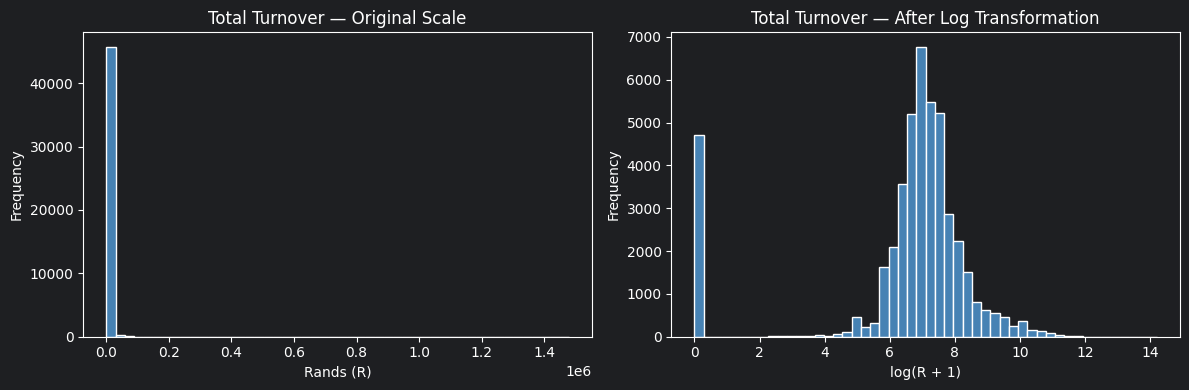


  Plot saved to outputs/figures/


In [13]:
# ============================================================
# CELL 13: TOTAL TURNOVER — LOG TRANSFORMATION (Section 3.2.2)
# We apply a log transformation to address the extreme right
# skew of 84.89. We use log1p which calculates log(value + 1)
# The +1 ensures zero values do not produce undefined results
# since log(0) is mathematically undefined.
# We do NOT remove outliers — they are legitimate billing
# events and the log transformation reduces their influence
# naturally without deleting real data.
# Missing values are handled in Section 3.2.3 — not here.
# ============================================================

import numpy as np

# ── Apply log1p transformation ────────────────────────────
# log1p(x) = log(x + 1)
# This handles zeros cleanly and compresses the extreme
# right tail that was causing skewness of 84.89
df['Total Turnover Log'] = np.log1p(df['Total Turnover'])

# ── Compare before and after skewness ────────────────────
original_skew = df['Total Turnover'].skew()
log_skew      = df['Total Turnover Log'].skew()

print("=" * 60)
print("TOTAL TURNOVER — LOG TRANSFORMATION RESULT")
print("=" * 60)
print(f"\n  Before transformation:")
print(f"    Skewness : {original_skew:.2f}")
print(f"    Min      : R{df['Total Turnover'].min():,.2f}")
print(f"    Median   : R{df['Total Turnover'].median():,.2f}")
print(f"    Max      : R{df['Total Turnover'].max():,.2f}")

print(f"\n  After log1p transformation:")
print(f"    Skewness : {log_skew:.2f}")
print(f"    Min      : {df['Total Turnover Log'].min():.4f}")
print(f"    Median   : {df['Total Turnover Log'].median():.4f}")
print(f"    Max      : {df['Total Turnover Log'].max():.4f}")

print(f"\n  Skewness reduction : {original_skew:.2f} → {log_skew:.2f}")
print(f"  Missing in log column : "
      f"{df['Total Turnover Log'].isnull().sum():,} "
      f"(same as original — treated in 3.2.3)")

# ── Drop the original Total Turnover column ───────────────
# The raw column is replaced by the log transformed version
# We keep the log version only going forward
df = df.drop(columns=['Total Turnover'])
print(f"\n  Total Turnover dropped — replaced by Total Turnover Log")
print(f"  Columns remaining : {df.shape[1]}")
print(f"\n  Columns in dataset:")
for col in df.columns:
    print(f"    {col}")

# ── Quick visual check — distribution comparison ──────────
# We plot both distributions side by side to confirm the
# transformation worked as expected
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Original — we reconstruct from log for the plot
original_vals = df['Total Turnover Log'].dropna()
axes[0].hist(np.expm1(original_vals), bins=50,
             color='steelblue', edgecolor='white')
axes[0].set_title('Total Turnover — Original Scale')
axes[0].set_xlabel('Rands (R)')
axes[0].set_ylabel('Frequency')

axes[1].hist(original_vals, bins=50,
             color='steelblue', edgecolor='white')
axes[1].set_title('Total Turnover — After Log Transformation')
axes[1].set_xlabel('log(R + 1)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()

# Save to outputs folder for the report
plt.savefig(
    r'C:\2026\MedicalBillingResearch\outputs\figures\total_turnover_log_transformation.png',
    dpi=150, bbox_inches='tight'
)
plt.show()
print("\n  Plot saved to outputs/figures/")

## 3.2.3 Missing Values

Anomaly detection is complete. We now assess missing values
across all retained variables and apply appropriate treatment.

Rules followed:
- Numeric variables: median imputation if skewed, mean if symmetric
- Categorical variables: mode imputation only if missingness is low
  and imputation is clinically sensible
- If imputation is not sensible, missing values become a category
- Variables excluded from modelling handle missing differently

In [14]:
# ============================================================
# CELL 14: MISSING VALUE ASSESSMENT (Section 3.2.3)
# We assess all retained variables for missing values.
# This happens AFTER anomaly detection so the counts reflect
# the cleaned data — not the raw data.
# We assess before imputing so we can make documented
# decisions for each variable.
# ============================================================

print("=" * 60)
print("MISSING VALUE SUMMARY — POST ANOMALY DETECTION")
print("=" * 60)

# Calculate missing counts and percentages for all columns
missing_summary = []
for col in df.columns:
    missing_n   = df[col].isnull().sum()
    missing_pct = missing_n / len(df) * 100
    missing_summary.append({
        'Variable':      col,
        'Missing Count': missing_n,
        'Missing %':     round(missing_pct, 2),
        'Dtype':         str(df[col].dtype)
    })

missing_df = pd.DataFrame(missing_summary)
missing_df = missing_df.sort_values('Missing %', ascending=False)

print(f"\n  {'Variable':<30} {'Missing N':>10} {'Missing %':>10}")
print(f"  {'-'*52}")
for _, row in missing_df.iterrows():
    flag = " ← needs treatment" if row['Missing Count'] > 0 else ""
    print(f"  {row['Variable']:<30} {row['Missing Count']:>10,} "
          f"{row['Missing %']:>9.2f}%{flag}")

print(f"\n  Total records    : {len(df):,}")
print(f"  Variables with missing : "
      f"{(missing_df['Missing Count'] > 0).sum()}")
print(f"  Variables complete     : "
      f"{(missing_df['Missing Count'] == 0).sum()}")

MISSING VALUE SUMMARY — POST ANOMALY DETECTION

  Variable                        Missing N  Missing %
  ----------------------------------------------------
  Total Turnover Log                  3,822      7.64% ← needs treatment
  Referring Doctor Name               3,159      6.32% ← needs treatment
  Capture Date                            0      0.00%
  Latest Capture Date                     0      0.00%
  Option                                  0      0.00%
  Posted Billing Group                    0      0.00%
  Invoice Number                          0      0.00%
  Gender                                  0      0.00%
  Specialty                               0      0.00%
  POSSIBLE PMB CALCULATED                 0      0.00%
  Debtor Status                           0      0.00%
  CONTRACTED/NON-CONTRACTED               0      0.00%
  Age Bracket                             0      0.00%
  ICD10 Chapter                           0      0.00%
  Facility Type                     

In [15]:
# ============================================================
# CELL 15: MISSING VALUE TREATMENT (Section 3.2.3)
# Only 2 variables require treatment.
#
# Total Turnover Log — 3,822 missing (7.64%)
# The original Total Turnover was right skewed (84.89)
# even after log transformation a slight skew remains (-1.84)
# For skewed variables median imputation is preferred over
# mean because the median is not pulled by extreme values.
# We impute with the median of the log transformed values
# calculated from the non-missing records only.
#
# Referring Doctor Name — 3,159 missing (6.32%)
# Missing here does not mean unknown — it means no referring
# doctor was recorded which means the patient had no referral.
# This is handled by converting to Has Referral in 3.2.4.
# A missing value becomes 0 (no referral) naturally.
# No imputation needed here.
# ============================================================

# ── Total Turnover Log — median imputation ────────────────
# Calculate median from non-missing values only
median_log = df['Total Turnover Log'].median()
print("=" * 60)
print("MISSING VALUE TREATMENT — Total Turnover Log")
print("=" * 60)
print(f"  Missing before imputation : "
      f"{df['Total Turnover Log'].isnull().sum():,}")
print(f"  Median log value          : {median_log:.4f}")
print(f"  Equivalent in Rands       : "
      f"R{(np.expm1(median_log)):,.2f}")
print(f"  Rationale                 : Median used because "
      f"skewness remains at -1.84 after transformation")

# Apply median imputation
df['Total Turnover Log'] = df['Total Turnover Log'].fillna(median_log)

print(f"  Missing after imputation  : "
      f"{df['Total Turnover Log'].isnull().sum():,}")

# ── Referring Doctor Name — no imputation needed ──────────
print("\n" + "=" * 60)
print("MISSING VALUE TREATMENT — Referring Doctor Name")
print("=" * 60)
print(f"  Missing count : {df['Referring Doctor Name'].isnull().sum():,}")
print(f"  Treatment     : No imputation applied")
print(f"  Reason        : Missing means no referral was recorded")
print(f"                  This is handled in Feature Engineering")
print(f"                  where missing becomes 0 in Has Referral")

# ── Final missing value confirmation ─────────────────────
print("\n" + "=" * 60)
print("MISSING VALUE SUMMARY — AFTER TREATMENT")
print("=" * 60)
remaining_missing = df.isnull().sum()
remaining_missing = remaining_missing[remaining_missing > 0]

if len(remaining_missing) == 0:
    print("  No missing values remain except Referring Doctor Name")
    print("  which will be resolved in Feature Engineering (3.2.4)")
else:
    print(remaining_missing.to_string())

print(f"\n  Total records : {len(df):,}")

# ── Build Table 3 for the report ─────────────────────────
# This is the formal missing value summary table required
# by the methodology template
print("\n" + "=" * 60)
print("TABLE 3: SUMMARY OF MISSING VALUES (Report Table)")
print("=" * 60)
table3_data = {
    'Variable':         ['Total Turnover Log',
                         'Referring Doctor Name',
                         'All other variables'],
    'Missing Count':    [3822, 3159, 0],
    'Missing %':        ['7.64%', '6.32%', '0.00%'],
    'Treatment':        [
        f'Median imputation — log value {median_log:.4f} '
        f'(R{np.expm1(median_log):,.2f})',
        'No imputation — missing means no referral, '
        'handled as 0 in Has Referral during Feature Engineering',
        'No action required'
    ]
}
table3 = pd.DataFrame(table3_data)
pd.set_option('display.max_colwidth', 80)
print(table3.to_string(index=False))

# Save table to outputs
table3.to_csv(
    r'C:\2026\MedicalBillingResearch\outputs\tables\table3_missing_values.csv',
    index=False
)
print("\n  Table 3 saved to outputs/tables/")

MISSING VALUE TREATMENT — Total Turnover Log
  Missing before imputation : 3,822
  Median log value          : 7.0179
  Equivalent in Rands       : R1,115.40
  Rationale                 : Median used because skewness remains at -1.84 after transformation
  Missing after imputation  : 0

MISSING VALUE TREATMENT — Referring Doctor Name
  Missing count : 3,159
  Treatment     : No imputation applied
  Reason        : Missing means no referral was recorded
                  This is handled in Feature Engineering
                  where missing becomes 0 in Has Referral

MISSING VALUE SUMMARY — AFTER TREATMENT
Referring Doctor Name    3159

  Total records : 50,000

TABLE 3: SUMMARY OF MISSING VALUES (Report Table)
             Variable  Missing Count Missing %                                                                                          Treatment
   Total Turnover Log           3822     7.64%                                                   Median imputation — log value 7.0179 

## 3.2.4 Feature Engineering

We now have a dataset that is anomaly-free and missing value
free across all modelling variables. In this section we
engineer four new variables:

1. **Has Referral** — binary indicator from Referring Doctor Name
2. **Processing Time** — days from Capture Date to Latest Capture Date
3. **Processing Class** — binary target variable (Timely / Delayed)

The threshold for Processing Class is determined by the
distribution of Processing Time observed in the data.

In [16]:
# ============================================================
# CELL 16: FEATURE ENGINEERING (Section 3.2.4)
# We engineer all new variables in this section.
# Has Referral resolves the last missing value issue.
# Processing Time and Processing Class build our target.
# ============================================================

# ── Engineer 1: Has Referral ──────────────────────────────
# Referring Doctor Name is a hashed identifier — too many
# unique values for direct modelling (3,741 unique hashes).
# What matters is whether a referral existed or not.
# Present hash = 1 (referral exists)
# Missing = 0 (no referral recorded)
print("=" * 60)
print("ENGINEERED VARIABLE 1: Has Referral")
print("=" * 60)

df['Has Referral'] = df['Referring Doctor Name'].notna().astype(int)

# Drop the original — no longer needed
df = df.drop(columns=['Referring Doctor Name'])

referral_counts = df['Has Referral'].value_counts()
for val, count in referral_counts.items():
    label = 'Has referral' if val == 1 else 'No referral'
    pct = count / len(df) * 100
    print(f"  {val} ({label:<15}) : {count:,} ({pct:.2f}%)")

print(f"  Missing remaining : {df['Has Referral'].isnull().sum()}")

# ── Engineer 2: Processing Time ───────────────────────────
# Measures how long an invoice spends inside the billing
# system from first capture to last recorded activity.
# Formula: Latest Capture Date minus Capture Date
# This is our agreed formula — clock starts when invoice
# enters the system, not when service was billed.
print("\n" + "=" * 60)
print("ENGINEERED VARIABLE 2: Processing Time")
print("=" * 60)

df['Processing Time'] = (
    df['Latest Capture Date'] - df['Capture Date']
).dt.days

print(f"  Formula   : Latest Capture Date - Capture Date")
print(f"  Missing   : {df['Processing Time'].isnull().sum():,}")
print(f"  Negative  : {(df['Processing Time'] < 0).sum():,}")
print(f"  Min       : {df['Processing Time'].min():.0f} days")
print(f"  Median    : {df['Processing Time'].median():.0f} days")
print(f"  Mean      : {df['Processing Time'].mean():.1f} days")
print(f"  Max       : {df['Processing Time'].max():.0f} days")
print(f"  Zero days : {(df['Processing Time'] == 0).sum():,} "
      f"({(df['Processing Time'] == 0).mean()*100:.1f}%)")

# ── Threshold sensitivity — confirm 14 days ───────────────
# We already investigated this in data understanding
# but we confirm the split here on the cleaned dataset
print(f"\n  Threshold sensitivity on cleaned dataset:")
print(f"  {'Threshold':<12} {'Timely':>10} {'Delayed':>10} "
      f"{'Timely %':>10} {'Delayed %':>10}")
print(f"  {'-'*54}")
for t in [7, 10, 14, 21, 30]:
    timely  = (df['Processing Time'] <= t).sum()
    delayed = (df['Processing Time'] > t).sum()
    print(f"  {t} days      {timely:>10,} {delayed:>10,} "
          f"{timely/len(df)*100:>9.1f}% "
          f"{delayed/len(df)*100:>9.1f}%")

# ── Engineer 3: Processing Class ─────────────────────────
# Binary target variable derived from Processing Time.
# Threshold: 14 days — selected based on data distribution
# showing 75.9% of invoices resolve within 14 days and
# the median processing time is 0 days confirming most
# invoices are resolved quickly inside the system.
# Timely  = Processing Time <= 14 days
# Delayed = Processing Time >  14 days
print("\n" + "=" * 60)
print("ENGINEERED VARIABLE 3: Processing Class")
print("=" * 60)

df['Processing Class'] = df['Processing Time'].apply(
    lambda x: 'Timely' if x <= 14 else 'Delayed'
)

class_counts = df['Processing Class'].value_counts()
for cls, count in class_counts.items():
    pct = count / len(df) * 100
    print(f"  {cls:<10} : {count:,} ({pct:.2f}%)")

print(f"\n  Threshold used    : 14 days")
print(f"  Missing           : "
      f"{df['Processing Class'].isnull().sum():,}")

# ── Drop date columns used only for engineering ───────────
# Capture Date and Latest Capture Date were kept only to
# build Processing Time and Processing Class.
# Processing Time itself is also not a predictor —
# it is the source of our target variable.
# We drop all three — only Processing Class goes to modelling.
df = df.drop(columns=['Capture Date',
                       'Latest Capture Date',
                       'Processing Time'])

print("\n" + "=" * 60)
print("DATASET AFTER FEATURE ENGINEERING")
print("=" * 60)
print(f"  Total records  : {len(df):,}")
print(f"  Total columns  : {df.shape[1]}")
print(f"\n  Final columns:")
for col in df.columns:
    role = 'TARGET' if col == 'Processing Class' else \
           'TRACK'  if col == 'Invoice Number'   else 'PREDICTOR'
    print(f"    [{role:<9}] {col}")

ENGINEERED VARIABLE 1: Has Referral
  1 (Has referral   ) : 46,841 (93.68%)
  0 (No referral    ) : 3,159 (6.32%)
  Missing remaining : 0

ENGINEERED VARIABLE 2: Processing Time
  Formula   : Latest Capture Date - Capture Date
  Missing   : 0
  Negative  : 0
  Min       : 0 days
  Median    : 0 days
  Mean      : 26.5 days
  Max       : 1640 days
  Zero days : 28,041 (56.1%)

  Threshold sensitivity on cleaned dataset:
  Threshold        Timely    Delayed   Timely %  Delayed %
  ------------------------------------------------------
  7 days          35,017     14,983      70.0%      30.0%
  10 days          36,373     13,627      72.7%      27.3%
  14 days          37,962     12,038      75.9%      24.1%
  21 days          40,057      9,943      80.1%      19.9%
  30 days          41,883      8,117      83.8%      16.2%

ENGINEERED VARIABLE 3: Processing Class
  Timely     : 37,962 (75.92%)
  Delayed    : 12,038 (24.08%)

  Threshold used    : 14 days
  Missing           : 0

DATASET 

In [17]:
# ============================================================
# CELL 17: SAVE CLEAN DATASET
# We save the cleaned dataset at this point — after anomaly
# detection, missing value treatment, and feature engineering
# are all complete. This is the dataset that will be used
# for correlations, descriptive analysis, and modelling.
# We save with Invoice Number included so we can always
# trace records back to the original data if needed.
# ============================================================

save_path = (
    r'C:\2026\MedicalBillingResearch\dataset'
    r'\private_patient_clean.csv'
)

df.to_csv(save_path, index=False)

print("=" * 60)
print("CLEAN DATASET SAVED")
print("=" * 60)
print(f"  Path          : {save_path}")
print(f"  Records       : {len(df):,}")
print(f"  Columns       : {df.shape[1]}")
print(f"  Target split  : "
      f"Timely {(df['Processing Class']=='Timely').sum():,} "
      f"({(df['Processing Class']=='Timely').mean()*100:.1f}%) | "
      f"Delayed {(df['Processing Class']=='Delayed').sum():,} "
      f"({(df['Processing Class']=='Delayed').mean()*100:.1f}%)")
print(f"\n  Columns saved:")
for col in df.columns:
    missing = df[col].isnull().sum()
    print(f"    {col:<35} missing: {missing}")

print(f"\n  Status: READY FOR SECTION 3.2.5")

CLEAN DATASET SAVED
  Path          : C:\2026\MedicalBillingResearch\dataset\private_patient_clean.csv
  Records       : 50,000
  Columns       : 14
  Target split  : Timely 37,962 (75.9%) | Delayed 12,038 (24.1%)

  Columns saved:
    Invoice Number                      missing: 0
    Option                              missing: 0
    Posted Billing Group                missing: 0
    Gender                              missing: 0
    Specialty                           missing: 0
    Debtor Status                       missing: 0
    POSSIBLE PMB CALCULATED             missing: 0
    CONTRACTED/NON-CONTRACTED           missing: 0
    Age Bracket                         missing: 0
    ICD10 Chapter                       missing: 0
    Facility Type                       missing: 0
    Total Turnover Log                  missing: 0
    Has Referral                        missing: 0
    Processing Class                    missing: 0

  Status: READY FOR SECTION 3.2.5


## 3.2.5 Correlations and Associations

Before modelling we test for relationships between predictor
variables and the target, and between predictors themselves.

The goal is two things:
1. Confirm which predictors are meaningfully associated
   with Processing Class — the target variable
2. Identify any predictors that are too strongly correlated
   with each other — multicollinearity — and remove the
   weaker one to avoid redundancy in the model

Tests used based on variable types:
- Categorical vs Categorical (predictor vs target):
  Cramer's V — measures strength of association
- Numeric vs Categorical (Total Turnover Log vs target):
  Point Biserial Correlation
- Categorical vs Categorical (predictor vs predictor):
  Cramer's V between all predictor pairs

In [18]:
# ============================================================
# CELL 18: ASSOCIATIONS — PREDICTORS VS TARGET (Section 3.2.5)
# We test every predictor against Processing Class.
# Categorical predictors use Cramer's V.
# Total Turnover Log uses Point Biserial Correlation.
# This tells us which predictors are worth keeping and
# gives us the first evidence-based view of variable
# importance before any model is built.
# ============================================================

from scipy.stats import chi2_contingency, pointbiserialr
import numpy as np

# ── Define predictor groups ───────────────────────────────
categorical_predictors = [
    'Option', 'Posted Billing Group', 'Gender',
    'Specialty', 'Debtor Status', 'POSSIBLE PMB CALCULATED',
    'CONTRACTED/NON-CONTRACTED', 'Age Bracket',
    'ICD10 Chapter', 'Facility Type', 'Has Referral'
]

numeric_predictors = ['Total Turnover Log']

target = 'Processing Class'

# ── Cramer's V function ───────────────────────────────────
# Cramer's V measures association strength between two
# categorical variables. Range is 0 (no association)
# to 1 (perfect association).
# Interpretation guidelines:
# < 0.10 = negligible
# 0.10 to 0.19 = weak
# 0.20 to 0.29 = moderate
# >= 0.30 = strong
def cramers_v(col1, col2, dataframe):
    confusion_matrix = pd.crosstab(
        dataframe[col1], dataframe[col2]
    )
    chi2 = chi2_contingency(confusion_matrix)[0]
    n    = confusion_matrix.sum().sum()
    r, c = confusion_matrix.shape
    v = np.sqrt(chi2 / (n * (min(r, c) - 1)))
    return round(v, 4)

# ── Test all categorical predictors vs target ─────────────
print("=" * 60)
print("CATEGORICAL PREDICTORS vs Processing Class")
print("Cramer's V Association Strength")
print("=" * 60)
print(f"\n  {'Predictor':<30} {'Cramer V':>10} {'Strength':>15}")
print(f"  {'-'*57}")

cat_results = []
for predictor in categorical_predictors:
    v = cramers_v(predictor, target, df)
    if v >= 0.30:
        strength = 'Strong'
    elif v >= 0.20:
        strength = 'Moderate'
    elif v >= 0.10:
        strength = 'Weak'
    else:
        strength = 'Negligible'
    cat_results.append((predictor, v, strength))
    print(f"  {predictor:<30} {v:>10.4f} {strength:>15}")

# ── Test numeric predictor vs target ─────────────────────
# Point Biserial Correlation measures association between
# a continuous variable and a binary categorical variable.
# We encode the target as binary: Delayed=1, Timely=0
print(f"\n{'=' * 60}")
print("NUMERIC PREDICTOR vs Processing Class")
print("Point Biserial Correlation")
print("=" * 60)
print(f"\n  {'Predictor':<30} {'Correlation':>12} {'Strength':>15}")
print(f"  {'-'*57}")

target_binary = (df[target] == 'Delayed').astype(int)
for predictor in numeric_predictors:
    corr, pval = pointbiserialr(
        df[predictor], target_binary
    )
    abs_corr = abs(corr)
    if abs_corr >= 0.30:
        strength = 'Strong'
    elif abs_corr >= 0.20:
        strength = 'Moderate'
    elif abs_corr >= 0.10:
        strength = 'Weak'
    else:
        strength = 'Negligible'
    print(f"  {predictor:<30} {corr:>12.4f} {strength:>15}")
    print(f"  {'p-value':<30} {pval:>12.4e}")

# ── Summary — which predictors to flag ───────────────────
print(f"\n{'=' * 60}")
print("SUMMARY — ASSOCIATION WITH TARGET")
print("=" * 60)
negligible = [p for p, v, s in cat_results if s == 'Negligible']
weak       = [p for p, v, s in cat_results if s == 'Weak']
moderate   = [p for p, v, s in cat_results if s == 'Moderate']
strong     = [p for p, v, s in cat_results if s == 'Strong']

print(f"\n  Strong association (V >= 0.30):")
for p in strong:
    print(f"    - {p}")
print(f"\n  Moderate association (0.20-0.29):")
for p in moderate:
    print(f"    - {p}")
print(f"\n  Weak association (0.10-0.19):")
for p in weak:
    print(f"    - {p}")
print(f"\n  Negligible association (< 0.10):")
for p in negligible:
    print(f"    - {p}")
print(f"\n  Note: Negligible association does not automatically")
print(f"  mean exclusion — we assess in context of all results")

CATEGORICAL PREDICTORS vs Processing Class
Cramer's V Association Strength

  Predictor                        Cramer V        Strength
  ---------------------------------------------------------
  Option                             0.0259      Negligible
  Posted Billing Group               0.1148            Weak
  Gender                             0.0154      Negligible
  Specialty                          0.1909            Weak
  Debtor Status                      0.1116            Weak
  POSSIBLE PMB CALCULATED            0.1144            Weak
  CONTRACTED/NON-CONTRACTED          0.0155      Negligible
  Age Bracket                        0.1228            Weak
  ICD10 Chapter                      0.1887            Weak
  Facility Type                      0.1913            Weak
  Has Referral                       0.0387      Negligible

NUMERIC PREDICTOR vs Processing Class
Point Biserial Correlation

  Predictor                       Correlation        Strength
  -------------

In [2]:
# ============================================================
# EXTRACT P-VALUES FROM CHI-SQUARE TESTS
# Chanel requested the significance values alongside Cramer's V
# so the decision to keep or drop each predictor is supported
# by statistical significance not just association strength.
# ============================================================

import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency, pointbiserialr

# Reload clean dataset
df = pd.read_csv(
    r'C:\2026\MedicalBillingResearch\dataset\private_patient_clean.csv'
)

print(f"Dataset loaded: {len(df):,} records, "
      f"{df.shape[1]} columns")
print(f"Columns: {list(df.columns)}\n")

# Predictors tested against target
predictors_to_test = [
    'Posted Billing Group', 'Specialty', 'Debtor Status',
    'Age Bracket', 'ICD10 Chapter', 'Facility Type',
    'Option', 'Gender'
]

print("=" * 75)
print("CHI-SQUARE P-VALUES — PREDICTOR vs PROCESSING CLASS")
print("=" * 75)

for pred in predictors_to_test:
    if pred in df.columns:
        contingency = pd.crosstab(df[pred], df['Processing Class'])
        chi2, p_value, dof, expected = chi2_contingency(contingency)
        sig = 'Significant' if p_value < 0.05 else 'Not significant'
        print(f"  {pred:<25} chi2={chi2:>10.2f}  "
              f"p={p_value:.6f}  ({sig})")

# Total Turnover Log uses point biserial
if 'Total Turnover Log' in df.columns:
    target_binary = (df['Processing Class'] == 'Delayed').astype(int)
    r, p = pointbiserialr(df['Total Turnover Log'], target_binary)
    sig = 'Significant' if p < 0.05 else 'Not significant'
    print(f"  {'Total Turnover Log':<25} r={r:>10.4f}  "
          f"p={p:.6f}  ({sig})")

Dataset loaded: 50,000 records, 12 columns
Columns: ['Invoice Number', 'Option', 'Posted Billing Group', 'Gender', 'Specialty', 'Debtor Status', 'Age Bracket', 'ICD10 Chapter', 'Facility Type', 'Total Turnover Log', 'Has Referral', 'Processing Class']

CHI-SQUARE P-VALUES — PREDICTOR vs PROCESSING CLASS
  Posted Billing Group      chi2=    658.62  p=0.000000  (Significant)
  Specialty                 chi2=   1822.46  p=0.000000  (Significant)
  Debtor Status             chi2=    623.00  p=0.000000  (Significant)
  Age Bracket               chi2=    754.09  p=0.000000  (Significant)
  ICD10 Chapter             chi2=   1779.61  p=0.000000  (Significant)
  Facility Type             chi2=   1830.62  p=0.000000  (Significant)
  Option                    chi2=     33.42  p=0.000000  (Significant)
  Gender                    chi2=     11.84  p=0.002684  (Significant)
  Total Turnover Log        r=    0.0067  p=0.132828  (Not significant)


In [19]:
# ============================================================
# CELL 19: MULTICOLLINEARITY — PREDICTORS VS PREDICTORS
# Section 3.2.5
# We test all pairs of categorical predictors against each
# other using Cramer's V to identify any predictors that
# are too strongly associated with each other.
# If two predictors are strongly correlated with each other
# but only weakly with the target, one of them is redundant.
# A Cramer's V above 0.70 between two predictors indicates
# problematic multicollinearity — we would drop the weaker
# of the two based on its association with the target.
# ============================================================

all_predictors = categorical_predictors + ['Total Turnover Log']

# ── Calculate Cramer's V for all predictor pairs ──────────
# We only do categorical vs categorical here
# Total Turnover Log vs categoricals uses point biserial
print("=" * 60)
print("PREDICTOR vs PREDICTOR — Cramer's V Matrix")
print("Checking for multicollinearity between predictors")
print("=" * 60)

# Build the matrix
n_cat = len(categorical_predictors)
vmatrix = np.zeros((n_cat, n_cat))

for i, p1 in enumerate(categorical_predictors):
    for j, p2 in enumerate(categorical_predictors):
        if i == j:
            vmatrix[i, j] = 1.0
        elif i < j:
            v = cramers_v(p1, p2, df)
            vmatrix[i, j] = v
            vmatrix[j, i] = v

# Display as DataFrame
short_names = {
    'Option':                   'Option',
    'Posted Billing Group':     'BillingGrp',
    'Gender':                   'Gender',
    'Specialty':                'Specialty',
    'Debtor Status':            'DebtorStat',
    'POSSIBLE PMB CALCULATED':  'PMB',
    'CONTRACTED/NON-CONTRACTED':'Contract',
    'Age Bracket':              'AgeBracket',
    'ICD10 Chapter':            'ICD10',
    'Facility Type':            'Facility',
    'Has Referral':             'HasReferral'
}

col_labels = [short_names[p] for p in categorical_predictors]
vmatrix_df = pd.DataFrame(
    vmatrix,
    index=col_labels,
    columns=col_labels
)

pd.set_option('display.float_format', '{:.3f}'.format)
print(f"\n{vmatrix_df.to_string()}")

# ── Flag high multicollinearity pairs ─────────────────────
# We flag any pair with Cramer's V above 0.50
# Above 0.50 means the two variables share substantial
# information — one may be redundant
print(f"\n{'=' * 60}")
print("HIGH ASSOCIATION PAIRS (Cramer V > 0.50)")
print("Potential multicollinearity concerns")
print("=" * 60)

high_pairs = []
for i, p1 in enumerate(categorical_predictors):
    for j, p2 in enumerate(categorical_predictors):
        if i < j and vmatrix[i, j] > 0.50:
            high_pairs.append((p1, p2, vmatrix[i, j]))

if high_pairs:
    for p1, p2, v in sorted(
        high_pairs, key=lambda x: x[2], reverse=True
    ):
        print(f"  {p1:<30} vs {p2:<30} V = {v:.4f}")
else:
    print("  No pairs with Cramer V above 0.50 found")

# ── Point biserial for Total Turnover Log vs target ───────
# Also check Total Turnover Log vs categorical predictors
print(f"\n{'=' * 60}")
print("TOTAL TURNOVER LOG vs CATEGORICAL PREDICTORS")
print("Point Biserial Correlation")
print("=" * 60)
print(f"\n  {'Predictor':<30} {'Correlation':>12}")
print(f"  {'-'*44}")
for predictor in categorical_predictors:
    # Encode categorical as numeric using label encoding
    # just for correlation calculation
    encoded = pd.factorize(df[predictor])[0]
    corr, pval = pointbiserialr(df['Total Turnover Log'], encoded)
    sig = "**" if pval < 0.05 else "  "
    print(f"  {predictor:<30} {corr:>12.4f} {sig}")

print(f"\n  ** = statistically significant at p < 0.05")

PREDICTOR vs PREDICTOR — Cramer's V Matrix
Checking for multicollinearity between predictors

             Option  BillingGrp  Gender  Specialty  DebtorStat   PMB  Contract  AgeBracket  ICD10  Facility  HasReferral
Option        1.000       0.014   0.012      0.019       0.042 0.016     0.018       0.006  0.047     0.012        0.005
BillingGrp    0.014       1.000   0.431      0.316       0.082 0.350     0.999       0.074  0.334     0.408        0.391
Gender        0.012       0.431   1.000      0.197       0.048 0.186     0.185       0.101  0.441     0.490        0.551
Specialty     0.019       0.316   0.197      1.000       0.143 0.444     0.350       0.100  0.436     0.396        0.217
DebtorStat    0.042       0.082   0.048      0.143       1.000 0.095     0.090       0.033  0.111     0.067        0.059
PMB           0.016       0.350   0.186      0.444       0.095 1.000     0.039       0.044  0.617     0.385        0.116
Contract      0.018       0.999   0.185      0.350       0.

In [20]:
# ============================================================
# CELL 20: APPLY MULTICOLLINEARITY DECISIONS (Section 3.2.5)
# Based on the association analysis we drop two variables:
#
# 1. CONTRACTED/NON-CONTRACTED — V = 0.9994 with Posted
#    Billing Group. Near perfect redundancy. Posted Billing
#    Group is richer and has stronger target association.
#
# 2. POSSIBLE PMB CALCULATED — V = 0.6169 with ICD10 Chapter.
#    PMB status is derived from diagnosis codes. ICD10 Chapter
#    contains all that information and more.
#
# All other variables are retained for modelling.
# Final exclusion decisions will be informed by variable
# importance scores from the models themselves.
# ============================================================

print("=" * 60)
print("MULTICOLLINEARITY DECISIONS")
print("=" * 60)

# ── Drop CONTRACTED/NON-CONTRACTED ────────────────────────
print(f"\n  Dropping: CONTRACTED/NON-CONTRACTED")
print(f"  Reason  : V = 0.9994 with Posted Billing Group")
print(f"            Near-perfect redundancy — billing group")
print(f"            already encodes contractual arrangement")
df = df.drop(columns=['CONTRACTED/NON-CONTRACTED'])

# ── Drop POSSIBLE PMB CALCULATED ─────────────────────────
print(f"\n  Dropping: POSSIBLE PMB CALCULATED")
print(f"  Reason  : V = 0.6169 with ICD10 Chapter")
print(f"            PMB status is derived from diagnosis codes")
print(f"            ICD10 Chapter contains richer clinical info")
df = df.drop(columns=['POSSIBLE PMB CALCULATED'])

# ── Confirm final predictor set ───────────────────────────
print(f"\n{'=' * 60}")
print("FINAL PREDICTOR SET AFTER MULTICOLLINEARITY TREATMENT")
print("=" * 60)
print(f"\n  {'Variable':<30} {'Association with Target':>25}")
print(f"  {'-'*57}")

# Recalculate associations for final predictor set
final_predictors = [
    col for col in df.columns
    if col not in ['Invoice Number', 'Processing Class']
]

for pred in final_predictors:
    if pred == 'Total Turnover Log':
        target_binary = (df['Processing Class'] == 'Delayed').astype(int)
        corr, _ = pointbiserialr(df[pred], target_binary)
        assoc = f"PB Corr = {corr:.4f}"
    else:
        v = cramers_v(pred, 'Processing Class', df)
        assoc = f"Cramer V = {v:.4f}"
    print(f"  {pred:<30} {assoc:>25}")

print(f"\n  Total predictors remaining : {len(final_predictors)}")
print(f"  Total records              : {len(df):,}")
print(f"  Target variable            : Processing Class")
print(f"  Target split               : "
      f"Timely {(df['Processing Class']=='Timely').sum():,} "
      f"({(df['Processing Class']=='Timely').mean()*100:.1f}%) | "
      f"Delayed {(df['Processing Class']=='Delayed').sum():,} "
      f"({(df['Processing Class']=='Delayed').mean()*100:.1f}%)")

# ── Resave clean dataset with final predictor set ─────────
save_path = (
    r'C:\2026\MedicalBillingResearch\dataset'
    r'\private_patient_clean.csv'
)
df.to_csv(save_path, index=False)
print(f"\n  Clean dataset resaved with final predictor set")
print(f"  Path: {save_path}")

MULTICOLLINEARITY DECISIONS

  Dropping: CONTRACTED/NON-CONTRACTED
  Reason  : V = 0.9994 with Posted Billing Group
            Near-perfect redundancy — billing group
            already encodes contractual arrangement

  Dropping: POSSIBLE PMB CALCULATED
  Reason  : V = 0.6169 with ICD10 Chapter
            PMB status is derived from diagnosis codes
            ICD10 Chapter contains richer clinical info

FINAL PREDICTOR SET AFTER MULTICOLLINEARITY TREATMENT

  Variable                         Association with Target
  ---------------------------------------------------------
  Option                                 Cramer V = 0.0259
  Posted Billing Group                   Cramer V = 0.1148
  Gender                                 Cramer V = 0.0154
  Specialty                              Cramer V = 0.1909
  Debtor Status                          Cramer V = 0.1116
  Age Bracket                            Cramer V = 0.1228
  ICD10 Chapter                          Cramer V = 0.1887
  

In [21]:
# ============================================================
# CELL 21: DESCRIPTIVE ANALYSES — DATASET PROFILE
# Section 3.2.6
# We describe the final clean dataset and produce the
# formal summary tables required by the template.
# Table 1: Numeric variables descriptive statistics
# Table 2: Categorical variables descriptive statistics
# These are the official report tables — accurately numbered.
# ============================================================

print("=" * 60)
print("FINAL CLEAN DATASET PROFILE")
print("=" * 60)
print(f"  Records    : {len(df):,}")
print(f"  Predictors : 10")
print(f"  Target     : Processing Class")
print(f"  Timely     : "
      f"{(df['Processing Class']=='Timely').sum():,} "
      f"({(df['Processing Class']=='Timely').mean()*100:.1f}%)")
print(f"  Delayed    : "
      f"{(df['Processing Class']=='Delayed').sum():,} "
      f"({(df['Processing Class']=='Delayed').mean()*100:.1f}%)")

# ── Table 1: Numeric Variables Descriptive Statistics ─────
# Only one numeric predictor: Total Turnover Log
print(f"\n{'=' * 60}")
print("TABLE 1: NUMERIC VARIABLES DESCRIPTIVE ANALYSIS")
print("=" * 60)
numeric_cols = ['Total Turnover Log']
num_stats = df[numeric_cols].describe().T
num_stats['skewness'] = df[numeric_cols].skew()
num_stats['missing'] = df[numeric_cols].isnull().sum()
num_stats['missing_pct'] = (
    df[numeric_cols].isnull().sum() / len(df) * 100
).round(2)

print(f"\n  {'Variable':<22} {'Count':>7} {'Min':>7} "
      f"{'Mean':>7} {'Median':>7} {'Max':>7} "
      f"{'Std':>7} {'Skew':>7}")
print(f"  {'-'*75}")
for col in numeric_cols:
    s = df[col]
    print(f"  {col:<22} {s.count():>7,} "
          f"{s.min():>7.2f} {s.mean():>7.2f} "
          f"{s.median():>7.2f} {s.max():>7.2f} "
          f"{s.std():>7.2f} {s.skew():>7.2f}")

# ── Table 2: Categorical Variables Descriptive Statistics ─
# For each categorical predictor we show all levels,
# counts, percentages and delay rate per category
print(f"\n{'=' * 60}")
print("TABLE 2: CATEGORICAL VARIABLES DESCRIPTIVE ANALYSIS")
print("With delay rates per category")
print("=" * 60)

categorical_cols = [
    col for col in df.columns
    if col not in ['Invoice Number', 'Processing Class',
                   'Total Turnover Log']
]

for col in categorical_cols:
    print(f"\n  Variable: {col}")
    print(f"  {'-'*65}")
    print(f"  {'Category':<40} {'Count':>7} {'%':>7} "
          f"{'Delayed':>8} {'Delay%':>8}")
    print(f"  {'-'*65}")

    vc = df[col].value_counts()
    total = len(df)

    for category, count in vc.items():
        pct = count / total * 100
        # Calculate delay rate for this category
        cat_df  = df[df[col] == category]
        delayed = (cat_df['Processing Class'] == 'Delayed').sum()
        delay_rate = delayed / len(cat_df) * 100
        print(f"  {str(category):<40} {count:>7,} "
              f"{pct:>7.1f}% {delayed:>8,} "
              f"{delay_rate:>7.1f}%")

FINAL CLEAN DATASET PROFILE
  Records    : 50,000
  Predictors : 10
  Target     : Processing Class
  Timely     : 37,962 (75.9%)
  Delayed    : 12,038 (24.1%)

TABLE 1: NUMERIC VARIABLES DESCRIPTIVE ANALYSIS

  Variable                 Count     Min    Mean  Median     Max     Std    Skew
  ---------------------------------------------------------------------------
  Total Turnover Log      50,000    0.00    6.53    7.02   14.21    2.29   -1.96

TABLE 2: CATEGORICAL VARIABLES DESCRIPTIVE ANALYSIS
With delay rates per category

  Variable: Option
  -----------------------------------------------------------------
  Category                                   Count       %  Delayed   Delay%
  -----------------------------------------------------------------
  Private Patient Acute                     49,981   100.0%   12,025    24.1%
  Private Insurance                             15     0.0%       13    86.7%
  Private Patient Pharmacy                       4     0.0%        0     0.0%


In [22]:
# ============================================================
# CELL 22: FINAL VARIABLE EXCLUSIONS (Section 3.2.6)
# Based on descriptive analysis and association testing
# we drop three more variables with clear evidence:
#
# Option — 99.96% single category, zero variation
# Gender — 0.2% difference in delay rate between M and F
# Total Turnover Log — non-significant p-value against target
#                      and negligible point biserial of 0.0067
#
# These decisions are evidence-based — we documented the
# delay rates and association strengths before dropping.
# ============================================================

print("=" * 60)
print("FINAL VARIABLE EXCLUSIONS")
print("=" * 60)

# ── Drop Option ───────────────────────────────────────────
print(f"\n  Dropping: Option")
print(f"  Reason  : 99.96% of records are Private Patient Acute")
print(f"            Effectively constant — no variation for")
print(f"            the model to learn from")
print(f"            Delay rates: Acute 24.1%, Insurance 86.7%")
print(f"            (Insurance has only 15 records — unreliable)")
df = df.drop(columns=['Option'])

# ── Drop Gender ───────────────────────────────────────────
print(f"\n  Dropping: Gender")
print(f"  Reason  : F delay rate 23.9%, M delay rate 24.1%")
print(f"            0.2 percentage point difference — no")
print(f"            meaningful relationship with processing delay")
print(f"            Cramer V = 0.0154 confirms negligible assoc")
df = df.drop(columns=['Gender'])

# ── Drop Total Turnover Log ───────────────────────────────
print(f"\n  Dropping: Total Turnover Log")
print(f"  Reason  : Point Biserial Corr = 0.0067, p = 0.1328")
print(f"            Non-significant — cannot confirm association")
print(f"            with target is different from zero")
print(f"            Billed amount does not predict processing speed")
df = df.drop(columns=['Total Turnover Log'])

# ── Final dataset confirmation ────────────────────────────
print(f"\n{'=' * 60}")
print("FINAL MODELLING DATASET")
print("=" * 60)
final_predictors = [
    col for col in df.columns
    if col not in ['Invoice Number', 'Processing Class']
]

print(f"\n  Records    : {len(df):,}")
print(f"  Predictors : {len(final_predictors)}")
print(f"  Target     : Processing Class")
print(f"\n  Final predictors:")
for pred in final_predictors:
    v = cramers_v(pred, 'Processing Class', df)
    print(f"    {pred:<30} Cramer V = {v:.4f}")

print(f"\n  Target split:")
print(f"    Timely  : "
      f"{(df['Processing Class']=='Timely').sum():,} "
      f"({(df['Processing Class']=='Timely').mean()*100:.1f}%)")
print(f"    Delayed : "
      f"{(df['Processing Class']=='Delayed').sum():,} "
      f"({(df['Processing Class']=='Delayed').mean()*100:.1f}%)")

# ── Save final modelling dataset ─────────────────────────
final_path = (
    r'C:\2026\MedicalBillingResearch\dataset'
    r'\private_patient_final.csv'
)
df.to_csv(final_path, index=False)
print(f"\n  Final dataset saved to:")
print(f"  {final_path}")

FINAL VARIABLE EXCLUSIONS

  Dropping: Option
  Reason  : 99.96% of records are Private Patient Acute
            Effectively constant — no variation for
            the model to learn from
            Delay rates: Acute 24.1%, Insurance 86.7%
            (Insurance has only 15 records — unreliable)

  Dropping: Gender
  Reason  : F delay rate 23.9%, M delay rate 24.1%
            0.2 percentage point difference — no
            meaningful relationship with processing delay
            Cramer V = 0.0154 confirms negligible assoc

  Dropping: Total Turnover Log
  Reason  : Point Biserial Corr = 0.0067, p = 0.1328
            Non-significant — cannot confirm association
            with target is different from zero
            Billed amount does not predict processing speed

FINAL MODELLING DATASET

  Records    : 50,000
  Predictors : 7
  Target     : Processing Class

  Final predictors:
    Posted Billing Group           Cramer V = 0.1148
    Specialty                      Cramer V =

## 3.2.7 Data Partitioning

The final clean dataset of 50,000 records is split into
a training set and a test set before any model is built.

The training set is used to build and tune the models.
The test set is held back completely and used only for
final model evaluation in Section 3.4.

We use stratified splitting to ensure the 75.9% Timely
and 24.1% Delayed class proportions are preserved in
both partitions.

In [23]:
# ============================================================
# CELL 23: DATA PARTITIONING (Section 3.2.7)
# We split the final dataset into 70% training and 30% test.
# Stratified split preserves the class balance in both sets.
# The test set is saved separately and will not be touched
# until final model evaluation — no peeking allowed.
# Invoice Number is excluded from modelling but kept in
# both files so records can always be traced back.
# ============================================================

from sklearn.model_selection import train_test_split

# ── Separate features, target and tracker ─────────────────
# Invoice Number is a tracker — not a predictor
# Processing Class is the target
X = df.drop(columns=['Invoice Number', 'Processing Class'])
y = df['Processing Class']
invoice_numbers = df['Invoice Number']

print("=" * 60)
print("DATA PARTITIONING (Section 3.2.7)")
print("=" * 60)
print(f"\n  Total records          : {len(df):,}")
print(f"  Predictors             : {X.shape[1]}")
print(f"  Target                 : Processing Class")
print(f"  Split ratio            : 70% train / 30% test")
print(f"  Method                 : Stratified split")
print(f"  Random state           : 42 (for reproducibility)")

# ── Perform stratified split ──────────────────────────────
# random_state=42 ensures anyone running this code gets
# exactly the same split — essential for reproducibility
X_train, X_test, y_train, y_test, inv_train, inv_test = (
    train_test_split(
        X, y, invoice_numbers,
        test_size=0.30,
        random_state=42,
        stratify=y  # preserves class proportions
    )
)

# ── Confirm split results ─────────────────────────────────
print(f"\n{'=' * 60}")
print("SPLIT RESULTS")
print("=" * 60)

for split_name, y_split, size in [
    ('Training set', y_train, len(y_train)),
    ('Test set',     y_test,  len(y_test))
]:
    timely  = (y_split == 'Timely').sum()
    delayed = (y_split == 'Delayed').sum()
    print(f"\n  {split_name}:")
    print(f"    Records : {size:,} "
          f"({size/len(df)*100:.1f}% of total)")
    print(f"    Timely  : {timely:,} "
          f"({timely/size*100:.1f}%)")
    print(f"    Delayed : {delayed:,} "
          f"({delayed/size*100:.1f}%)")

# ── Verify stratification worked ──────────────────────────
# The proportions should match the full dataset (75.9/24.1)
print(f"\n  Stratification check:")
print(f"    Full dataset Delayed % : "
      f"{(y=='Delayed').mean()*100:.2f}%")
print(f"    Training Delayed %     : "
      f"{(y_train=='Delayed').mean()*100:.2f}%")
print(f"    Test Delayed %         : "
      f"{(y_test=='Delayed').mean()*100:.2f}%")
print(f"    Status: "
      f"{'OK — proportions preserved' if abs((y_train=='Delayed').mean() - (y=='Delayed').mean()) < 0.001 else 'CHECK — proportions differ'}")

# ── Save training and test sets ───────────────────────────
# We reconstruct full DataFrames with Invoice Number
# so records can always be traced back to source
train_df = pd.concat([
    inv_train.reset_index(drop=True),
    X_train.reset_index(drop=True),
    y_train.reset_index(drop=True)
], axis=1)

test_df = pd.concat([
    inv_test.reset_index(drop=True),
    X_test.reset_index(drop=True),
    y_test.reset_index(drop=True)
], axis=1)

train_path = (
    r'C:\2026\MedicalBillingResearch\dataset'
    r'\train_set.csv'
)
test_path = (
    r'C:\2026\MedicalBillingResearch\dataset'
    r'\test_set.csv'
)

train_df.to_csv(train_path, index=False)
test_df.to_csv(test_path,  index=False)

print(f"\n{'=' * 60}")
print("DATASETS SAVED")
print("=" * 60)
print(f"\n  Training set : {train_path}")
print(f"    Records    : {len(train_df):,}")
print(f"\n  Test set     : {test_path}")
print(f"    Records    : {len(test_df):,}")
print(f"\n  IMPORTANT: Test set is held back until final")
print(f"  model evaluation. Do not use it for training")
print(f"  or tuning any model.")
print(f"\n  Section 3.2 Data Preparation — COMPLETE")

DATA PARTITIONING (Section 3.2.7)

  Total records          : 50,000
  Predictors             : 7
  Target                 : Processing Class
  Split ratio            : 70% train / 30% test
  Method                 : Stratified split
  Random state           : 42 (for reproducibility)

SPLIT RESULTS

  Training set:
    Records : 35,000 (70.0% of total)
    Timely  : 26,573 (75.9%)
    Delayed : 8,427 (24.1%)

  Test set:
    Records : 15,000 (30.0% of total)
    Timely  : 11,389 (75.9%)
    Delayed : 3,611 (24.1%)

  Stratification check:
    Full dataset Delayed % : 24.08%
    Training Delayed %     : 24.08%
    Test Delayed %         : 24.07%
    Status: OK — proportions preserved

DATASETS SAVED

  Training set : C:\2026\MedicalBillingResearch\dataset\train_set.csv
    Records    : 35,000

  Test set     : C:\2026\MedicalBillingResearch\dataset\test_set.csv
    Records    : 15,000

  IMPORTANT: Test set is held back until final
  model evaluation. Do not use it for training
  or tu

In [24]:
# ============================================================
# CELL 23: DATA PARTITIONING (Section 3.2.7)
# We explicitly load private_patient_final.csv here to
# confirm we are partitioning the correct final dataset —
# not relying on whatever df happens to be in memory.
# This makes the cell self-contained and reproducible.
# Training set: 70% — used to build and tune models
# Test set: 30% — held back for final evaluation only
# Stratified split preserves 75.9%/24.1% class proportions.
# ============================================================

from sklearn.model_selection import train_test_split

# ── Load the confirmed final dataset explicitly ───────────
# We load from file — not from memory — so this cell is
# trustworthy regardless of what happened earlier in session
final_path = (
    r'C:\2026\MedicalBillingResearch\dataset'
    r'\private_patient_final.csv'
)

df_final = pd.read_csv(final_path)

print("=" * 60)
print("LOADING FINAL DATASET FOR PARTITIONING")
print("=" * 60)
print(f"  File loaded   : private_patient_final.csv")
print(f"  Records       : {len(df_final):,}")
print(f"  Columns       : {df_final.shape[1]}")
print(f"\n  Columns confirmed:")
for col in df_final.columns:
    role = 'TARGET'    if col == 'Processing Class' else \
           'TRACK'     if col == 'Invoice Number'   else 'PREDICTOR'
    print(f"    [{role:<9}] {col}")

# ── Confirm target distribution before splitting ──────────
print(f"\n  Target distribution:")
vc = df_final['Processing Class'].value_counts()
for cls, count in vc.items():
    print(f"    {cls:<10} : {count:,} ({count/len(df_final)*100:.1f}%)")

# ── Separate features, target and tracker ─────────────────
X           = df_final.drop(columns=['Invoice Number', 'Processing Class'])
y           = df_final['Processing Class']
inv_numbers = df_final['Invoice Number']

print(f"\n{'=' * 60}")
print("DATA PARTITIONING (Section 3.2.7)")
print("=" * 60)
print(f"  Total records  : {len(df_final):,}")
print(f"  Predictors     : {X.shape[1]}")
print(f"  Split ratio    : 70% train / 30% test")
print(f"  Method         : Stratified split")
print(f"  Random state   : 42 (for reproducibility)")

# ── Perform stratified split ──────────────────────────────
X_train, X_test, y_train, y_test, inv_train, inv_test = (
    train_test_split(
        X, y, inv_numbers,
        test_size=0.30,
        random_state=42,
        stratify=y
    )
)

# ── Confirm split results ─────────────────────────────────
print(f"\n{'=' * 60}")
print("SPLIT RESULTS")
print("=" * 60)
for split_name, y_split, size in [
    ('Training set', y_train, len(y_train)),
    ('Test set',     y_test,  len(y_test))
]:
    timely  = (y_split == 'Timely').sum()
    delayed = (y_split == 'Delayed').sum()
    print(f"\n  {split_name}:")
    print(f"    Records : {size:,} "
          f"({size/len(df_final)*100:.1f}% of total)")
    print(f"    Timely  : {timely:,} ({timely/size*100:.1f}%)")
    print(f"    Delayed : {delayed:,} ({delayed/size*100:.1f}%)")

# ── Verify stratification ─────────────────────────────────
full_delayed  = (y == 'Delayed').mean()
train_delayed = (y_train == 'Delayed').mean()
test_delayed  = (y_test == 'Delayed').mean()

print(f"\n  Stratification check:")
print(f"    Full dataset Delayed % : {full_delayed*100:.2f}%")
print(f"    Training Delayed %     : {train_delayed*100:.2f}%")
print(f"    Test Delayed %         : {test_delayed*100:.2f}%")
print(f"    Status: "
      f"{'OK — proportions preserved' if abs(train_delayed - full_delayed) < 0.001 else 'CHECK — proportions differ'}")

# ── Reconstruct and save full train/test files ────────────
train_df = pd.concat([
    inv_train.reset_index(drop=True),
    X_train.reset_index(drop=True),
    y_train.reset_index(drop=True)
], axis=1)

test_df = pd.concat([
    inv_test.reset_index(drop=True),
    X_test.reset_index(drop=True),
    y_test.reset_index(drop=True)
], axis=1)

train_save = (
    r'C:\2026\MedicalBillingResearch\dataset\train_set.csv'
)
test_save = (
    r'C:\2026\MedicalBillingResearch\dataset\test_set.csv'
)

train_df.to_csv(train_save, index=False)
test_df.to_csv(test_save,   index=False)

print(f"\n{'=' * 60}")
print("DATASETS SAVED")
print("=" * 60)
print(f"\n  Training set : {train_save}")
print(f"    Records    : {len(train_df):,}")
print(f"\n  Test set     : {test_save}")
print(f"    Records    : {len(test_df):,}")
print(f"\n  IMPORTANT: Test set is held back until final")
print(f"  model evaluation. Do not use it for training")
print(f"  or tuning any model.")
print(f"\n  Section 3.2 Data Preparation — COMPLETE")

LOADING FINAL DATASET FOR PARTITIONING
  File loaded   : private_patient_final.csv
  Records       : 50,000
  Columns       : 9

  Columns confirmed:
    [TRACK    ] Invoice Number
    [PREDICTOR] Posted Billing Group
    [PREDICTOR] Specialty
    [PREDICTOR] Debtor Status
    [PREDICTOR] Age Bracket
    [PREDICTOR] ICD10 Chapter
    [PREDICTOR] Facility Type
    [PREDICTOR] Has Referral
    [TARGET   ] Processing Class

  Target distribution:
    Timely     : 37,962 (75.9%)
    Delayed    : 12,038 (24.1%)

DATA PARTITIONING (Section 3.2.7)
  Total records  : 50,000
  Predictors     : 7
  Split ratio    : 70% train / 30% test
  Method         : Stratified split
  Random state   : 42 (for reproducibility)

SPLIT RESULTS

  Training set:
    Records : 35,000 (70.0% of total)
    Timely  : 26,573 (75.9%)
    Delayed : 8,427 (24.1%)

  Test set:
    Records : 15,000 (30.0% of total)
    Timely  : 11,389 (75.9%)
    Delayed : 3,611 (24.1%)

  Stratification check:
    Full dataset Delayed %

In [3]:
# ============================================================
# RELOAD CLEAN DATASET
# The kernel was restarted so df is not in memory.
# We reload from private_patient_clean.csv which contains
# all cleaning done up to and including feature engineering.
# This is the correct file to load because it has all the
# anomaly detection and missing value work already applied.
# ============================================================

import pandas as pd
import numpy as np

df = pd.read_csv(
    r'C:\2026\MedicalBillingResearch\dataset\private_patient_clean.csv'
)

print("=" * 60)
print("DATASET RELOADED")
print("=" * 60)
print(f"  Records  : {len(df):,}")
print(f"  Columns  : {df.shape[1]}")
print(f"\n  Columns:")
for col in df.columns:
    print(f"    {col}")

print(f"\n  Specialty unique values : {df['Specialty'].nunique()}")
print(f"  Specialty categories:")
print(df['Specialty'].value_counts().to_string())

DATASET RELOADED
  Records  : 50,000
  Columns  : 12

  Columns:
    Invoice Number
    Option
    Posted Billing Group
    Gender
    Specialty
    Debtor Status
    Age Bracket
    ICD10 Chapter
    Facility Type
    Total Turnover Log
    Has Referral
    Processing Class

  Specialty unique values : 17
  Specialty categories:
Specialty
Physician                         12672
Ophthalmologist                    9233
General Surgeon                    4826
General Dental Practice            3860
General Medical Practice           3161
Urologist                          2631
Psychiatrist                       2270
Allied Health                      2005
Surgical Specialist                1844
Paediatrician                      1831
Obstetrician and Gynaecologist     1416
Orthopaedic Surgeon                 989
Other                               959
Neurologist                         725
Psychologist                        698
Diagnostic and Pathology            681
Anaesthetist      

In [4]:
# ============================================================
# CELL 8B: SPECIALTY — FURTHER CONSOLIDATION (Section 3.2.2)
# Chanel flagged 17 categories as too many for modelling.
# We consolidate further from 17 to 9 categories based on
# clinical groupings as suggested by the supervisor.
# ============================================================

specialty_final_mapping = {
    # Mental Health — mental and behavioural health practitioners
    'Psychologist':     'Mental Health',
    'Psychiatrist':     'Mental Health',

    # Surgical — all theatre-based operative specialties
    'General Surgeon':      'Surgical',
    'Surgical Specialist':  'Surgical',
    'Orthopaedic Surgeon':  'Surgical',
    'Anaesthetist':         'Surgical',

    # General Practice — undifferentiated patient care
    'Physician':                'General Practice',
    'General Medical Practice': 'General Practice',

    # Kept individually — clinically distinct with enough records
    'Ophthalmologist':                'Ophthalmologist',
    'General Dental Practice':        'General Dental Practice',
    'Paediatrician':                  'Paediatrician',
    'Obstetrician and Gynaecologist': 'Obstetrics and Gynaecology',

    # Specialist Medicine — organ specific and diagnostic
    'Neurologist':              'Specialist Medicine',
    'Urologist':                'Specialist Medicine',
    'Diagnostic and Pathology': 'Specialist Medicine',

    # Allied Health and Other
    'Allied Health':    'Allied Health and Other',
    'Other':            'Allied Health and Other',
}

df['Specialty'] = df['Specialty'].replace(specialty_final_mapping)

print("=" * 60)
print("SPECIALTY — FINAL CONSOLIDATION RESULT")
print("=" * 60)
vc = df['Specialty'].value_counts(dropna=False)
total = len(df)
print(f"\n  {'Category':<30} {'Count':>7} {'%':>7} "
      f"{'Delayed':>8} {'Delay%':>8}")
print(f"  {'-'*65}")
for cat, count in vc.items():
    pct      = count / total * 100
    cat_df   = df[df['Specialty'] == cat]
    delayed  = (cat_df['Processing Class'] == 'Delayed').sum()
    delay_rate = delayed / len(cat_df) * 100
    print(f"  {str(cat):<30} {count:>7,} {pct:>7.1f}% "
          f"{delayed:>8,} {delay_rate:>7.1f}%")

print(f"\n  Categories before : 17")
print(f"  Categories after  : {df['Specialty'].nunique()}")
print(f"  Total records     : {total:,}")

SPECIALTY — FINAL CONSOLIDATION RESULT

  Category                         Count       %  Delayed   Delay%
  -----------------------------------------------------------------
  General Practice                15,833    31.7%    4,706    29.7%
  Ophthalmologist                  9,233    18.5%    1,629    17.6%
  Surgical                         7,858    15.7%    1,995    25.4%
  Specialist Medicine              4,037     8.1%      843    20.9%
  General Dental Practice          3,860     7.7%      407    10.5%
  Mental Health                    2,968     5.9%    1,065    35.9%
  Allied Health and Other          2,964     5.9%      795    26.8%
  Paediatrician                    1,831     3.7%      468    25.6%
  Obstetrics and Gynaecology       1,416     2.8%      130     9.2%

  Categories before : 17
  Categories after  : 9
  Total records     : 50,000


In [6]:
# ============================================================
# CELL 10B: ICD10 CHAPTER — FURTHER CONSOLIDATION
# Section 3.2.2
# Chanel flagged 18 categories as too many — adding 18 levels
# to a model produces 17 dummy variables which risks
# multicollinearity. We consolidate from 18 to 9 categories
# using broader disease groupings based on clinical similarity
# and delay rate proximity.
# ============================================================

icd10_final_mapping = {
    # Infectious and Respiratory — communicable and airway
    # conditions share similar clinical urgency and billing
    # COVID-19 codes grouped here as respiratory/infectious
    'Infectious and Parasitic Diseases':    'Infectious and Respiratory',
    'Respiratory System Diseases':          'Infectious and Respiratory',
    'COVID-19 and Special Codes':           'Infectious and Respiratory',

    # Cancer and Blood — kept as distinct group
    # Complex treatment pathways and billing arrangements
    'Cancer and Blood Diseases':            'Cancer and Blood',

    # Mental Health — kept as distinct group
    # High delay rate of 34.8% makes it stand out clearly
    'Mental and Behavioural Disorders':     'Mental Health',

    # Cardiovascular and Metabolic — chronic systemic conditions
    # Both involve long-term disease management billing
    'Circulatory System Diseases':          'Cardiovascular and Metabolic',
    'Endocrine and Metabolic Diseases':     'Cardiovascular and Metabolic',

    # Digestive and Genitourinary — abdominal and urological
    # Similar administrative billing patterns
    'Digestive System Diseases':            'Digestive and Genitourinary',
    'Genitourinary Diseases':               'Digestive and Genitourinary',

    # Neurological and Structural — movement, trauma and
    # nervous system conditions with similar complexity
    'Nervous System Diseases':              'Neurological and Structural',
    'Musculoskeletal Diseases':             'Neurological and Structural',
    'Injury and Trauma':                    'Neurological and Structural',

    # Routine and Outpatient — low complexity encounters
    # All three have low delay rates (14-22%) reflecting
    # the administrative simplicity of routine visits
    'Eye and Ear Diseases':                 'Routine and Outpatient',
    'Skin Diseases':                        'Routine and Outpatient',
    'Health Status and Contact':            'Routine and Outpatient',
    'Symptoms and Abnormal Findings':       'Routine and Outpatient',

    # Maternal and Developmental — kept as distinct group
    # Clinically and administratively distinct billing pathway
    'Maternal and Developmental':           'Maternal and Developmental',

    # Unknown — missing diagnostic information
    # Cannot be clinically grouped so retained separately
    'Unknown':                              'Unknown',
}

df['ICD10 Chapter'] = df['ICD10 Chapter'].replace(icd10_final_mapping)

print("=" * 60)
print("ICD10 CHAPTER — FINAL CONSOLIDATION RESULT")
print("=" * 60)
vc = df['ICD10 Chapter'].value_counts(dropna=False)
total = len(df)
print(f"\n  {'Category':<30} {'Count':>7} {'%':>7} "
      f"{'Delayed':>8} {'Delay%':>8}")
print(f"  {'-'*65}")
for cat, count in vc.items():
    pct      = count / total * 100
    cat_df   = df[df['ICD10 Chapter'] == cat]
    delayed  = (cat_df['Processing Class'] == 'Delayed').sum()
    delay_rate = delayed / len(cat_df) * 100
    print(f"  {str(cat):<30} {count:>7,} {pct:>7.1f}% "
          f"{delayed:>8,} {delay_rate:>7.1f}%")

print(f"\n  Categories before : 18")
print(f"  Categories after  : {df['ICD10 Chapter'].nunique()}")
print(f"  Total records     : {total:,}")

ICD10 CHAPTER — FINAL CONSOLIDATION RESULT

  Category                         Count       %  Delayed   Delay%
  -----------------------------------------------------------------
  Routine and Outpatient          18,499    37.0%    3,030    16.4%
  Digestive and Genitourinary      6,529    13.1%    1,608    24.6%
  Cardiovascular and Metabolic     5,241    10.5%    1,605    30.6%
  Infectious and Respiratory       4,979    10.0%    1,661    33.4%
  Neurological and Structural      4,298     8.6%    1,043    24.3%
  Unknown                          3,816     7.6%      832    21.8%
  Mental Health                    3,177     6.4%    1,107    34.8%
  Cancer and Blood                 2,809     5.6%      936    33.3%
  Maternal and Developmental         652     1.3%      216    33.1%

  Categories before : 18
  Categories after  : 9
  Total records     : 50,000


In [8]:
# ============================================================
# CELL 22B: REAPPLY VARIABLE EXCLUSIONS AND RESAVE
# After consolidating Specialty to 9 and ICD10 Chapter to 9
# we reapply the same exclusion decisions from Cell 22.
# We drop: Option, Gender, Total Turnover Log,
# CONTRACTED/NON-CONTRACTED, POSSIBLE PMB CALCULATED
# These were excluded based on evidence from Section 3.2.5
# and 3.2.6 — those decisions have not changed.
# We then resave all three dataset files so everything
# downstream uses the updated consolidations.
# ============================================================

# ── Confirm current columns before exclusions ─────────────
print("=" * 60)
print("COLUMNS BEFORE FINAL EXCLUSIONS")
print("=" * 60)
for col in df.columns:
    print(f"  {col}")

# ── Drop variables based on previous evidence ─────────────
# Option       — 99.96% single category, no variation
# Gender       — 0.2 percentage point difference M vs F
# Total Turnover Log — non-significant p-value (0.1328)
# These three were dropped in Cell 22

# Check which of these still exist in current df
cols_to_drop = []
for col in ['Option', 'Gender', 'Total Turnover Log']:
    if col in df.columns:
        cols_to_drop.append(col)
        print(f"\n  Dropping: {col}")

if cols_to_drop:
    df = df.drop(columns=cols_to_drop)

# ── Confirm final predictor set ───────────────────────────
print("\n" + "=" * 60)
print("FINAL MODELLING DATASET — AFTER CONSOLIDATION")
print("=" * 60)

final_predictors = [
    col for col in df.columns
    if col not in ['Invoice Number', 'Processing Class']
]

print(f"\n  Records    : {len(df):,}")
print(f"  Predictors : {len(final_predictors)}")
print(f"\n  Final predictors and category counts:")
for pred in final_predictors:
    n_cats = df[pred].nunique()
    print(f"    {pred:<30} {n_cats} categories")

print(f"\n  Target split:")
print(f"    Timely  : {(df['Processing Class']=='Timely').sum():,} "
      f"({(df['Processing Class']=='Timely').mean()*100:.1f}%)")
print(f"    Delayed : {(df['Processing Class']=='Delayed').sum():,} "
      f"({(df['Processing Class']=='Delayed').mean()*100:.1f}%)")

# ── Resave private_patient_final.csv ─────────────────────
final_path = (
    r'C:\2026\MedicalBillingResearch\dataset'
    r'\private_patient_final.csv'
)
df.to_csv(final_path, index=False)
print(f"\n  private_patient_final.csv resaved")

# ── Redo stratified train/test split ─────────────────────
# We must redo the split so train and test sets also
# reflect the new Specialty and ICD10 consolidations
from sklearn.model_selection import train_test_split

X           = df.drop(columns=['Invoice Number', 'Processing Class'])
y           = df['Processing Class']
inv_numbers = df['Invoice Number']

X_train, X_test, y_train, y_test, inv_train, inv_test = (
    train_test_split(
        X, y, inv_numbers,
        test_size=0.30,
        random_state=42,
        stratify=y
    )
)

# Reconstruct full train and test DataFrames
train_df = pd.concat([
    inv_train.reset_index(drop=True),
    X_train.reset_index(drop=True),
    y_train.reset_index(drop=True)
], axis=1)

test_df = pd.concat([
    inv_test.reset_index(drop=True),
    X_test.reset_index(drop=True),
    y_test.reset_index(drop=True)
], axis=1)

# Save
train_path = (
    r'C:\2026\MedicalBillingResearch\dataset\train_set.csv'
)
test_path = (
    r'C:\2026\MedicalBillingResearch\dataset\test_set.csv'
)
train_df.to_csv(train_path, index=False)
test_df.to_csv(test_path, index=False)

# ── Confirm split ─────────────────────────────────────────
print(f"\n{'=' * 60}")
print("TRAIN / TEST SPLIT — CONFIRMED")
print("=" * 60)
print(f"\n  Training set : {len(train_df):,} records")
print(f"    Timely     : {(y_train=='Timely').sum():,} "
      f"({(y_train=='Timely').mean()*100:.1f}%)")
print(f"    Delayed    : {(y_train=='Delayed').sum():,} "
      f"({(y_train=='Delayed').mean()*100:.1f}%)")
print(f"\n  Test set     : {len(test_df):,} records")
print(f"    Timely     : {(y_test=='Timely').sum():,} "
      f"({(y_test=='Timely').mean()*100:.1f}%)")
print(f"    Delayed    : {(y_test=='Delayed').sum():,} "
      f"({(y_test=='Delayed').mean()*100:.1f}%)")
print(f"\n  Stratification check:")
print(f"    Full dataset Delayed % : "
      f"{(y=='Delayed').mean()*100:.2f}%")
print(f"    Training Delayed %     : "
      f"{(y_train=='Delayed').mean()*100:.2f}%")
print(f"    Test Delayed %         : "
      f"{(y_test=='Delayed').mean()*100:.2f}%")
print(f"\n  All three files resaved successfully")
print(f"  Data preparation pipeline — COMPLETE")

COLUMNS BEFORE FINAL EXCLUSIONS
  Invoice Number
  Option
  Posted Billing Group
  Gender
  Specialty
  Debtor Status
  Age Bracket
  ICD10 Chapter
  Facility Type
  Total Turnover Log
  Has Referral
  Processing Class

  Dropping: Option

  Dropping: Gender

  Dropping: Total Turnover Log

FINAL MODELLING DATASET — AFTER CONSOLIDATION

  Records    : 50,000
  Predictors : 7

  Final predictors and category counts:
    Posted Billing Group           13 categories
    Specialty                      9 categories
    Debtor Status                  7 categories
    Age Bracket                    7 categories
    ICD10 Chapter                  9 categories
    Facility Type                  9 categories
    Has Referral                   2 categories

  Target split:
    Timely  : 37,962 (75.9%)
    Delayed : 12,038 (24.1%)

  private_patient_final.csv resaved

TRAIN / TEST SPLIT — CONFIRMED

  Training set : 35,000 records
    Timely     : 26,573 (75.9%)
    Delayed    : 8,427 (24.1%)

  T

In [9]:
# ============================================================
# CELL 22C: DROP HAS.REFERRAL FROM FINAL DATASET
# Has.Referral showed a negligible association with the target
# variable (Cramer V = 0.039) and a severe predictor imbalance
# of 93.7% vs 6.3% which would give the model insufficient
# data to learn reliably from the minority group.
# We drop it and resave all three dataset files.
# ============================================================

# Reload final dataset explicitly from file
df_final = pd.read_csv(
    r'C:\2026\MedicalBillingResearch\dataset\private_patient_final.csv'
)

print("=" * 60)
print("BEFORE DROPPING HAS.REFERRAL")
print("=" * 60)
print(f"  Records    : {len(df_final):,}")
print(f"  Predictors : {df_final.shape[1] - 2}")
print(f"  Columns    : {list(df_final.columns)}")

# Drop Has Referral
df_final = df_final.drop(columns=['Has Referral'])

print("\n" + "=" * 60)
print("AFTER DROPPING HAS.REFERRAL")
print("=" * 60)
print(f"  Records    : {len(df_final):,}")
print(f"  Predictors : {df_final.shape[1] - 2}")
print(f"  Columns    : {list(df_final.columns)}")

# Resave private_patient_final.csv
final_path = (
    r'C:\2026\MedicalBillingResearch\dataset'
    r'\private_patient_final.csv'
)
df_final.to_csv(final_path, index=False)

# Redo train/test split
X           = df_final.drop(columns=['Invoice Number', 'Processing Class'])
y           = df_final['Processing Class']
inv_numbers = df_final['Invoice Number']

X_train, X_test, y_train, y_test, inv_train, inv_test = (
    train_test_split(
        X, y, inv_numbers,
        test_size=0.30,
        random_state=42,
        stratify=y
    )
)

train_df = pd.concat([
    inv_train.reset_index(drop=True),
    X_train.reset_index(drop=True),
    y_train.reset_index(drop=True)
], axis=1)

test_df = pd.concat([
    inv_test.reset_index(drop=True),
    X_test.reset_index(drop=True),
    y_test.reset_index(drop=True)
], axis=1)

train_df.to_csv(
    r'C:\2026\MedicalBillingResearch\dataset\train_set.csv',
    index=False
)
test_df.to_csv(
    r'C:\2026\MedicalBillingResearch\dataset\test_set.csv',
    index=False
)

print("\n" + "=" * 60)
print("TRAIN / TEST SPLIT CONFIRMED")
print("=" * 60)
print(f"  Training set : {len(train_df):,} records")
print(f"    Timely     : {(y_train=='Timely').sum():,} "
      f"({(y_train=='Timely').mean()*100:.1f}%)")
print(f"    Delayed    : {(y_train=='Delayed').sum():,} "
      f"({(y_train=='Delayed').mean()*100:.1f}%)")
print(f"\n  Test set     : {len(test_df):,} records")
print(f"    Timely     : {(y_test=='Timely').sum():,} "
      f"({(y_test=='Timely').mean()*100:.1f}%)")
print(f"    Delayed    : {(y_test=='Delayed').sum():,} "
      f"({(y_test=='Delayed').mean()*100:.1f}%)")
print(f"\n  Stratification check:")
print(f"    Full Delayed %     : {(y=='Delayed').mean()*100:.2f}%")
print(f"    Training Delayed % : {(y_train=='Delayed').mean()*100:.2f}%")
print(f"    Test Delayed %     : {(y_test=='Delayed').mean()*100:.2f}%")
print(f"\n  All files resaved. Final predictor count: "
      f"{X.shape[1]}")

BEFORE DROPPING HAS.REFERRAL
  Records    : 50,000
  Predictors : 7
  Columns    : ['Invoice Number', 'Posted Billing Group', 'Specialty', 'Debtor Status', 'Age Bracket', 'ICD10 Chapter', 'Facility Type', 'Has Referral', 'Processing Class']

AFTER DROPPING HAS.REFERRAL
  Records    : 50,000
  Predictors : 6
  Columns    : ['Invoice Number', 'Posted Billing Group', 'Specialty', 'Debtor Status', 'Age Bracket', 'ICD10 Chapter', 'Facility Type', 'Processing Class']

TRAIN / TEST SPLIT CONFIRMED
  Training set : 35,000 records
    Timely     : 26,573 (75.9%)
    Delayed    : 8,427 (24.1%)

  Test set     : 15,000 records
    Timely     : 11,389 (75.9%)
    Delayed    : 3,611 (24.1%)

  Stratification check:
    Full Delayed %     : 24.08%
    Training Delayed % : 24.08%
    Test Delayed %     : 24.07%

  All files resaved. Final predictor count: 6


In [1]:
# ============================================================
# CHI-SQUARE P-VALUES FOR MULTICOLLINEARITY PAIRS
# Chanel requested p-values for Table 11 — the predictor
# vs predictor multicollinearity pairs.
# We compute chi-square p-values for the two pairs that
# showed V > 0.50 in our analysis.
# ============================================================

import pandas as pd
from scipy.stats import chi2_contingency

# Reload raw data — we need columns dropped during preparation
df_raw = pd.read_excel(
    r'C:\2026\MedicalBillingResearch\dataset\PRIVATE PATIENT.xlsx',
    engine='openpyxl'
)

print("=" * 60)
print("MULTICOLLINEARITY PAIR P-VALUES")
print("=" * 60)

# Pair 1: Posted Billing Group vs CONTRACTED/NON-CONTRACTED
# Use raw column names from the original dataset
pairs = [
    ('Posted Billing Group', 'CONTRACTED/NON-CONTRACTED'),
    ('POSSIBLE PMB CALCULATED', 'Primary ICD10'),
]

for v1, v2 in pairs:
    if v1 in df_raw.columns and v2 in df_raw.columns:
        contingency = pd.crosstab(
            df_raw[v1].fillna('Missing'),
            df_raw[v2].fillna('Missing')
        )
        chi2, p, dof, expected = chi2_contingency(contingency)
        print(f"\n  {v1}")
        print(f"  vs {v2}")
        print(f"    chi2 = {chi2:,.2f}")
        print(f"    p-value = {p:.6f}")
        print(f"    Significant: {'Yes' if p < 0.05 else 'No'}")

MULTICOLLINEARITY PAIR P-VALUES

  Posted Billing Group
  vs CONTRACTED/NON-CONTRACTED
    chi2 = 50,000.00
    p-value = 0.000000
    Significant: Yes

  POSSIBLE PMB CALCULATED
  vs Primary ICD10
    chi2 = 46,182.14
    p-value = 0.000000
    Significant: Yes
